# Neural Adaptive Tension for Multi-Geometry Curve Subdivision

Code repository for:

> **"Neural Adaptive Tension for Multi-Geometry Curve Subdivision in E², S² and
H² by H. Ugail and N. Howard"**  
>


## Install / check dependencies

In [ ]:
# PyTorch and standard libraries are pre-installed on Colab.
# Uncomment if running elsewhere:
# !pip install torch torchvision --quiet
# !pip install numpy matplotlib scipy --quiet

import importlib
for pkg in ['torch', 'numpy', 'matplotlib', 'scipy']:
    v = importlib.import_module(pkg).__version__
    print(f"  {pkg:<12} {v}")

  torch        2.10.0+cu128
  numpy        2.0.2
  matplotlib   3.10.0
  scipy        1.16.3


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import shutil

Mounted at /content/drive


## Imports & device setup

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import math, time, os
from pathlib import Path
from collections import defaultdict
from typing import List, Optional

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

OUTDIR = Path('outputs')
OUTDIR.mkdir(exist_ok=True)
print(f"Outputs: {OUTDIR.resolve()}")

Device : cuda
GPU    : NVIDIA A100-SXM4-40GB
VRAM   : 42.4 GB
Outputs: /content/outputs


## Hyperparameters  (edit these)

In [ ]:
CFG = dict(
    # ── Data ──────────────────────────────────────────────────────────
    n_per_geometry   = 400,     # curves per geometry type
    n_ctrl           = 12,      # control polygon vertices
    n_gt             = 1000,    # ground-truth curve resolution
    val_fraction     = 0.20,
    seed             = 42,

    # ── Model ──────────────────────────────────────────────────────────
    hidden           = 128,
    n_res_blocks     = 4,
    dropout          = 0.05,

    # ── Training ───────────────────────────────────────────────────────
    n_epochs         = 300,     # upper bound only — early stopping fires first
    lr               = 1e-3,
    weight_decay     = 1e-4,
    warmup_epochs    = 5,
    batch_size       = 8,
    grad_clip        = 0.5,
    n_neural_iters   = 2,
    n_warmup_iters   = 1,
    val_every        = 10,
    save_every       = 50,

    # ── Loss weights ────────────────────────────────────────────────────
    # Global fallbacks
    lambda_chamfer   = 1.00,
    lambda_smooth    = 0.05,    # global fallback (used if geom-specific not set)
    lambda_bending   = 0.0001,
    lambda_equiv     = 0.10,
    n_equiv_xforms   = 2,

    # Per-geometry smoothness weights  ← v4 KEY ADDITION
    # Rationale: S² G¹ underperformed log-exp 6pt (0.500 vs 0.410) in v3.
    # Increasing λ_smooth_S pushes the network to prioritise tangent continuity
    # on S² — at a small fidelity cost that is acceptable given the network
    # already trails log-exp on S² mean-NN anyway.
    lambda_smooth_E  = 0.05,    # Euclidean — unchanged from v3
    lambda_smooth_S  = 0.15,    # Spherical  — 3× increase targets G¹ gap
    lambda_smooth_H  = 0.05,    # Hyperbolic — unchanged; H² G¹ already best-in-class

    # ── Early stopping ─────────────────────────────────────────────────
    patience         = 25,
    min_delta        = 1e-5,
    lr_patience      = 10,
    lr_factor        = 0.5,

    # ── Evaluation ─────────────────────────────────────────────────────
    n_eval_iters     = 5,

    # ── OOD evaluation ─────────────────────────────────────────────────
    n_ood_per_geom   = 100,     # random polygons per geometry for OOD test
    n_ood_ctrl       = 12,      # OOD control points (same as training)
)

EPS         = 1e-7
ALPHA_MIN   = -math.pi / 4 + 0.02
ALPHA_MAX   =  math.pi / 4 - 0.02
ALPHA_RANGE =  ALPHA_MAX - ALPHA_MIN

def _geom_lambda_smooth(geometry, cfg):
    """Return geometry-specific smoothness weight, falling back to global."""
    key = {'euclidean': 'lambda_smooth_E',
           'spherical':  'lambda_smooth_S',
           'hyperbolic': 'lambda_smooth_H'}[geometry]
    return cfg.get(key, cfg['lambda_smooth'])

print("Configuration loaded.")
print(f"  Max epochs          : {CFG['n_epochs']} (early stopping patience={CFG['patience']} val-checks)")
print(f"  Loss weights        : chamfer={CFG['lambda_chamfer']}  bending={CFG['lambda_bending']}  equiv={CFG['lambda_equiv']}")
print(f"  Per-geom λ_smooth   : E²={CFG['lambda_smooth_E']}  S²={CFG['lambda_smooth_S']}  H²={CFG['lambda_smooth_H']}")


Configuration loaded.
  Max epochs          : 300 (early stopping patience=25 val-checks)
  Loss weights        : chamfer=1.0  bending=0.0001  equiv=0.1
  Per-geom λ_smooth   : E²=0.05  S²=0.15  H²=0.05


## Differentiable geometry (E², S², H²)

In [ ]:
def rot2d(alphas: torch.Tensor, vecs: torch.Tensor) -> torch.Tensor:
    """Rotate each 2-D vector by its corresponding angle. (N,),(N,2)→(N,2)."""
    c = alphas.cos().unsqueeze(-1)
    s = alphas.sin().unsqueeze(-1)
    return torch.cat([c*vecs[:,0:1] - s*vecs[:,1:2],
                      s*vecs[:,0:1] + c*vecs[:,1:2]], dim=-1)

# ── E² ──────────────────────────────────────────────────────────────────────

def eucl_edge_lengths(P):
    return (P.roll(-1,0) - P).norm(dim=-1).clamp(min=EPS)

def eucl_exterior_angles(P):
    T = P.roll(-1,0) - P
    T = T / T.norm(dim=-1,keepdim=True).clamp(min=EPS)
    V = P - P.roll(1,0)
    V = V / V.norm(dim=-1,keepdim=True).clamp(min=EPS)
    cos_a = (V*T).sum(-1).clamp(-1+EPS, 1-EPS)
    sin_a = V[:,0]*T[:,1] - V[:,1]*T[:,0]
    return torch.atan2(sin_a, cos_a)

def eucl_subdivide_step(P, alphas):
    e     = eucl_edge_lengths(P)
    T_hat = (P.roll(-1,0)-P) / e.unsqueeze(-1)
    abs_a = alphas.abs().clamp(max=math.pi/4-0.01)
    denom = torch.sin(math.pi - 2.0*abs_a).clamp(min=EPS)
    e_new = torch.sin(abs_a) / denom * e
    new_pts = P + e_new.unsqueeze(-1) * rot2d(alphas, T_hat)
    N = P.shape[0]
    Q = torch.empty(2*N, 2, device=P.device, dtype=P.dtype)
    Q[0::2] = P;  Q[1::2] = new_pts
    return Q

# ── S² ──────────────────────────────────────────────────────────────────────

def sph_norm(P):
    return P / P.norm(dim=-1,keepdim=True).clamp(min=EPS)

def sph_edge_lengths(P):
    cos_d = (P*P.roll(-1,0)).sum(-1).clamp(-1+EPS,1-EPS)
    return cos_d.acos().clamp(min=EPS)

def sph_tan_vec(p, q):
    cos_d = (p*q).sum(-1,keepdim=True).clamp(-1+EPS,1-EPS)
    sin_d = (1-cos_d**2).clamp(min=EPS).sqrt()
    return (q - cos_d*p) / sin_d

def sph_exterior_angles(P):
    T = sph_tan_vec(P, P.roll(-1,0))
    V = -sph_tan_vec(P, P.roll(1,0))
    cos_a = (V*T).sum(-1).clamp(-1+EPS,1-EPS)
    sin_a = (torch.cross(V,T,dim=-1)*P).sum(-1)
    return torch.atan2(sin_a, cos_a)

def sph_subdivide_step(P, alphas):
    e    = sph_edge_lengths(P)
    T    = sph_tan_vec(P, P.roll(-1,0))
    abs_a = alphas.abs().clamp(max=math.pi/4-0.01)
    e_new = torch.atan(
        torch.tan(e/2).clamp(-1e4,1e4) / abs_a.cos().clamp(min=EPS)
    ).clamp(min=EPS, max=math.pi/2-0.01)
    cross = torch.cross(P, T, dim=-1)
    U = alphas.cos().unsqueeze(-1)*T + alphas.sin().unsqueeze(-1)*cross
    new_pts = sph_norm(e_new.cos().unsqueeze(-1)*P + e_new.sin().unsqueeze(-1)*U)
    N = P.shape[0]
    Q = torch.empty(2*N, 3, device=P.device, dtype=P.dtype)
    Q[0::2] = P;  Q[1::2] = new_pts
    return Q

# ── H² (Poincaré disk) ───────────────────────────────────────────────────────

def hyp_mob_add(z, w):
    zw   = (z*w).sum(-1,keepdim=True)
    z_sq = (z*z).sum(-1,keepdim=True)
    w_sq = (w*w).sum(-1,keepdim=True)
    num  = (1+2*zw+w_sq)*z + (1-z_sq)*w
    den  = (1+2*zw+z_sq*w_sq).clamp(min=EPS)
    return num/den

def hyp_edge_lengths(P):
    Q   = P.roll(-1,0)
    d2  = ((P-Q)**2).sum(-1)
    lz  = (1-(P*P).sum(-1)).clamp(min=EPS)
    lq  = (1-(Q*Q).sum(-1)).clamp(min=EPS)
    arg = (1 + 2*d2/(lz*lq)).clamp(min=1+EPS)
    return torch.acosh(arg).clamp(min=EPS)

def hyp_tan_dir(z, w):
    v = hyp_mob_add(-z, w)
    return v / v.norm(dim=-1,keepdim=True).clamp(min=EPS)

def hyp_exterior_angles(P):
    T = hyp_tan_dir(P, P.roll(-1,0))
    V = -hyp_tan_dir(P, P.roll(1,0))
    cos_a = (V*T).sum(-1).clamp(-1+EPS,1-EPS)
    sin_a = V[:,0]*T[:,1] - V[:,1]*T[:,0]
    return torch.atan2(sin_a, cos_a)

def hyp_geodesic(z, u_hat, t):
    step   = torch.tanh((t/2).clamp(max=6.0)).unsqueeze(-1) * u_hat
    result = hyp_mob_add(z, step)
    nrm    = result.norm(dim=-1,keepdim=True)
    return torch.where(nrm>0.999, result*0.999/nrm.clamp(min=EPS), result)

def hyp_subdivide_step(P, alphas):
    e     = hyp_edge_lengths(P)
    T     = hyp_tan_dir(P, P.roll(-1,0))
    abs_a = alphas.abs().clamp(max=math.pi/4-0.01)
    tanh_e = torch.tanh(e/2).clamp(-1+EPS,1-EPS)
    e_new  = torch.atanh(
        (tanh_e/abs_a.cos().clamp(min=EPS)).clamp(-1+EPS,1-EPS)
    ).clamp(min=EPS, max=4.0)
    U = rot2d(alphas, T)
    new_pts = hyp_geodesic(P, U, e_new)
    N = P.shape[0]
    Q = torch.empty(2*N, 2, device=P.device, dtype=P.dtype)
    Q[0::2] = P;  Q[1::2] = new_pts
    return Q

# ── Feature extraction ───────────────────────────────────────────────────────

def geom_code(geometry):
    return {'euclidean': 0.0, 'spherical': 1.0, 'hyperbolic': -1.0}[geometry]

def extract_features(P, geometry, kappa_code):
    """7-dim normalised intrinsic features for every edge. Returns (N,7)."""
    if geometry == 'euclidean':
        d = eucl_exterior_angles(P);  e = eucl_edge_lengths(P)
    elif geometry == 'spherical':
        d = sph_exterior_angles(P);   e = sph_edge_lengths(P)
    else:
        d = hyp_exterior_angles(P);   e = hyp_edge_lengths(P)
    e_mean  = e.mean().clamp(min=EPS)
    kappa_f = torch.full((P.shape[0],), kappa_code, device=P.device, dtype=P.dtype)
    return torch.stack([
        d.roll(1)  / math.pi,
        d          / math.pi,
        d.roll(-1) / math.pi,
        d.roll(-2) / math.pi,
        e          / e_mean,
        e.roll(-1) / e_mean,
        kappa_f,
    ], dim=1)

# ── Isometry helpers (equivariance loss) ────────────────────────────────────

def rand_rot2d(device):
    theta = torch.rand(1).item() * 2*math.pi
    c, s  = math.cos(theta), math.sin(theta)
    return torch.tensor([[c,-s],[s,c]], dtype=torch.float32, device=device)

def rand_so3(device):
    M = torch.randn(3,3,device=device)
    Q, _ = torch.linalg.qr(M)
    if torch.det(Q) < 0: Q[:,0] *= -1
    return Q


# ── Riemannian log / exp maps (for log-exp subdivision baseline) ─────────────

def sph_log_map(P, Q):
    """Spherical log map at P pointing toward Q. Returns tangent vector (N,3)."""
    cos_d = (P * Q).sum(-1, keepdim=True).clamp(-1 + EPS, 1 - EPS)
    sin_d = (1 - cos_d ** 2).clamp(min=EPS).sqrt()
    u     = (Q - cos_d * P) / sin_d
    theta = cos_d.acos()
    return theta * u

def sph_exp_map(P, V):
    """Spherical exp map at P in tangent direction V. Returns point on S² (N,3)."""
    nv = V.norm(dim=-1, keepdim=True).clamp(min=EPS)
    return nv.cos() * P + nv.sin() * (V / nv)

def hyp_log_map(Z, W):
    """Poincare-disk log map at Z toward W. Returns tangent vector (N,2)."""
    V    = hyp_mob_add(-Z, W)
    nv   = V.norm(dim=-1, keepdim=True).clamp(min=EPS)
    z_sq = (Z * Z).sum(-1, keepdim=True).clamp(max=1 - EPS)
    return (2.0 / (1.0 - z_sq)) * torch.atanh(nv.clamp(max=1 - EPS)) * (V / nv)

def hyp_exp_map(Z, V):
    """Poincare-disk exp map at Z in tangent direction V. Returns point in H² (N,2)."""
    nv   = V.norm(dim=-1, keepdim=True).clamp(min=EPS)
    z_sq = (Z * Z).sum(-1, keepdim=True).clamp(max=1 - EPS)
    t    = torch.tanh((nv * (1.0 - z_sq) / 2.0).clamp(max=6.0))
    step = t * (V / nv)
    res  = hyp_mob_add(Z, step)
    nrm  = res.norm(dim=-1, keepdim=True)
    return torch.where(nrm > 0.999, res * 0.999 / nrm.clamp(min=EPS), res)

def log_map(P, Q, geometry):
    """Geometry-aware log map: tangent vector at P pointing toward Q."""
    if geometry == 'euclidean':  return Q - P
    elif geometry == 'spherical': return sph_log_map(P, Q)
    else:                         return hyp_log_map(P, Q)

def exp_map(P, V, geometry):
    """Geometry-aware exp map: point reached from P in tangent direction V."""
    if geometry == 'euclidean':  return P + V
    elif geometry == 'spherical': return sph_exp_map(P, V)
    else:                         return hyp_exp_map(P, V)

print("Geometry module ready.")

Geometry module ready.


## Neural network: NeuralOperator

In [ ]:
import torch.nn as nn  # re-import guard: prevents bare `nn` variable from shadowing
class ResBlock(nn.Module):
    def __init__(self, dim, dropout=0.05):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim), nn.LayerNorm(dim), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim), nn.LayerNorm(dim),
        )
        self.act = nn.GELU()
    def forward(self, x):
        return self.act(x + self.net(x))


class NeuralOperator(nn.Module):
    """
    Geometry-aware neural subdivision network.

    Input  (B,7): [δ_{j-1}/π, δ_j/π, δ_{j+1}/π, δ_{j+2}/π,
                   e_j/ē, e_{j+1}/ē, κ_code]
    Output (B,1): α ∈ [ALPHA_MIN, ALPHA_MAX]  — G¹ safe zone by construction.

    The geometry type κ ∈ {−1,0,1} is embedded via a learned 8-dim vector
    so one model handles E², S², H² simultaneously.
    """
    def __init__(self, hidden=128, n_res_blocks=4, dropout=0.05):
        super().__init__()
        G = 8   # geometry embedding dim
        self.geom_embed = nn.Embedding(3, G)
        self.input_proj = nn.Sequential(
            nn.Linear(6+G, hidden), nn.LayerNorm(hidden), nn.GELU())
        self.trunk = nn.ModuleList(
            [ResBlock(hidden, dropout) for _ in range(n_res_blocks)])
        self.head = nn.Sequential(
            nn.Linear(hidden, 32), nn.GELU(),
            nn.Linear(32, 1), nn.Sigmoid())
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, feats):
        intrinsic = feats[:, :6]
        idx       = (feats[:,6]+1).long().clamp(0,2)
        g_emb     = self.geom_embed(idx)
        x         = self.input_proj(torch.cat([intrinsic, g_emb], -1))
        for block in self.trunk:
            x = block(x)
        return ALPHA_MIN + ALPHA_RANGE * self.head(x)   # (B,1) in [α_min,α_max]

    def n_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


_t = NeuralOperator(hidden=CFG['hidden'], n_res_blocks=CFG['n_res_blocks'])
_f = torch.randn(10,7); _f[:,6] = 0.0
_o = _t(_f)
assert _o.shape==(10,1) and (_o.abs() < math.pi/4).all()
print(f"NeuralOperator  |  params: {_t.n_params():,}")
print(f"  output range: [{_o.min().item():.4f}, {_o.max().item():.4f}]"
      f"  (safe zone: [{ALPHA_MIN:.4f}, {ALPHA_MAX:.4f}])")

NeuralOperator  |  params: 140,505
  output range: [-0.4059, 0.6966]  (safe zone: [-0.7654, 0.7654])


## Synthetic data generation

In [ ]:
def _norm2d(pts):
    pts = pts - pts.mean(0)
    return pts / (np.max(np.linalg.norm(pts,axis=1)) + 1e-12)

def _sph_norm(pts):
    return pts / (np.linalg.norm(pts,axis=1,keepdims=True) + 1e-12)

def make_eucl_ellipse(a=2.,b=1.,n=1000):
    t=np.linspace(0,2*np.pi,n,endpoint=False)
    return _norm2d(np.stack([a*np.cos(t),b*np.sin(t)],1))

def make_eucl_fourier(seed=0,n_freqs=4,n=1000):
    rng=np.random.RandomState(seed); t=np.linspace(0,2*np.pi,n,endpoint=False)
    x,y=np.zeros(n),np.zeros(n)
    for k in range(1,n_freqs+1):
        ax,bx=rng.randn(2)/k**1.5; ay,by=rng.randn(2)/k**1.5
        x+=ax*np.cos(k*t)+bx*np.sin(k*t); y+=ay*np.cos(k*t)+by*np.sin(k*t)
    return _norm2d(np.stack([x,y],1))

def make_eucl_superellipse(n_exp=4.,n=1000):
    t=np.linspace(0,2*np.pi,n,endpoint=False)
    x=np.sign(np.cos(t))*np.abs(np.cos(t))**(2/max(n_exp,.5))
    y=np.sign(np.sin(t))*np.abs(np.sin(t))**(2/max(n_exp,.5))
    return _norm2d(np.stack([x,y],1))

def make_sph_lissajous(a=2,b=3,n=1000):
    t=np.linspace(0,2*np.pi,n,endpoint=False)
    return _sph_norm(np.stack([np.cos(a*t),np.cos(b*t+np.pi/4),
                                np.sin(a*t)*np.sin(b*t)],1))

def make_sph_polar_fourier(seed=0,n_freqs=3,n=1000):
    rng=np.random.RandomState(seed); t=np.linspace(0,2*np.pi,n,endpoint=False)
    theta=np.pi/2+sum(rng.randn()/k**1.5*np.cos(k*t+rng.rand()*2*np.pi)
                      for k in range(1,n_freqs+1))
    theta=np.clip(theta,.1,np.pi-.1)
    phi=sum(rng.randn()/k*np.cos(k*t+rng.rand()*2*np.pi)
            for k in range(1,n_freqs+1))
    return _sph_norm(np.stack([np.sin(theta)*np.cos(phi),
                                np.sin(theta)*np.sin(phi),np.cos(theta)],1))

def make_sph_great_circle(seed=0,n=1000):
    rng=np.random.RandomState(seed); t=np.linspace(0,2*np.pi,n,endpoint=False)
    z=.3*rng.rand()*np.sin(rng.choice([2,3,4])*t+rng.rand()*2*np.pi)
    return _sph_norm(np.stack([np.cos(t),np.sin(t),z],1))

def make_hyp_from_euclidean(seed=0,n_freqs=3,scale=.58,n=1000):
    pts=make_eucl_fourier(seed=seed,n_freqs=n_freqs,n=n)*scale
    nrm=np.linalg.norm(pts,axis=1,keepdims=True)
    return np.where(nrm>.97,pts*.97/(nrm+1e-12),pts).astype(np.float32)

def make_hyp_circle(r=.5,n=1000):
    t=np.linspace(0,2*np.pi,n,endpoint=False)
    return np.stack([r*np.cos(t),r*np.sin(t)],1).astype(np.float32)

def make_hyp_offset_ellipse(seed=0,n=1000):
    rng=np.random.RandomState(seed)
    a,b=.35+rng.rand()*.3,.25+rng.rand()*.25; cx,cy=rng.rand()*.15,rng.rand()*.15
    t=np.linspace(0,2*np.pi,n,endpoint=False)
    pts=np.stack([cx+a*np.cos(t),cy+b*np.sin(t)],1)
    nrm=np.linalg.norm(pts,axis=1,keepdims=True)
    return np.where(nrm>.95,pts*.95/(nrm+1e-12),pts).astype(np.float32)

def sample_arclength(curve, n_ctrl):
    """
    Sample n_ctrl points arc-length uniformly from a *closed* curve.

    The closure segment (last point → first point) is included in the
    cumulative arc-length so that sampling is consistent with the closed
    polygon geometry used during subdivision.
    """
    # Segment lengths including wrap-around closure segment
    segs = np.concatenate([curve[1:] - curve[:-1],
                           curve[:1]  - curve[-1:]], axis=0)  # (N, dim)
    seg_len = np.linalg.norm(segs, axis=1)                    # (N,)
    arc = np.concatenate([[0], np.cumsum(seg_len)])            # (N+1,)
    total_len = arc[-1]
    tgts = np.linspace(0, total_len, n_ctrl, endpoint=False)
    idx  = np.clip(np.searchsorted(arc, tgts), 0, len(curve) - 1)
    return curve[idx].copy()


class SubdivDataset(Dataset):
    def __init__(self,n_per_geom=400,n_ctrl=12,n_gt=1000,
                 val_frac=.20,split='train',seed=42):
        rng=np.random.RandomState(seed); samples=[]
        for i in range(n_per_geom):
            c=i%4
            a,b=.6+rng.rand()*1.4,.6+rng.rand()*1.4
            gt=(make_eucl_ellipse(a,b)   if c==0 else
                make_eucl_fourier(seed=seed+i*7,n_freqs=3)  if c==1 else
                make_eucl_fourier(seed=seed+i*13,n_freqs=4) if c==2 else
                make_eucl_superellipse(2.+rng.rand()*4.))
            ctrl=sample_arclength(gt,n_ctrl)
            samples.append(dict(ctrl=ctrl.astype(np.float32),
                                gt=gt.astype(np.float32),
                                geometry='euclidean',kappa=0.))
        for i in range(n_per_geom):
            c=i%3
            gt=(make_sph_lissajous(rng.choice([2,3,4]),rng.choice([3,4,5])) if c==0 else
                make_sph_polar_fourier(seed=seed+1000+i,n_freqs=rng.choice([2,3])) if c==1 else
                make_sph_great_circle(seed=seed+1000+i))
            ctrl=sample_arclength(gt,n_ctrl)
            samples.append(dict(ctrl=ctrl.astype(np.float32),
                                gt=gt.astype(np.float32),
                                geometry='spherical',kappa=1.))
        for i in range(n_per_geom):
            c=i%3
            gt=(make_hyp_from_euclidean(seed=seed+2000+i,
                    n_freqs=rng.choice([2,3,4]),scale=.50+rng.rand()*.12) if c==0 else
                make_hyp_circle(r=.30+rng.rand()*.40) if c==1 else
                make_hyp_offset_ellipse(seed=seed+2000+i))
            ctrl=sample_arclength(gt,n_ctrl)
            samples.append(dict(ctrl=ctrl.astype(np.float32),
                                gt=gt.astype(np.float32),
                                geometry='hyperbolic',kappa=-1.))
        perm=rng.permutation(len(samples)); n_val=max(1,int(len(samples)*val_frac))
        self.samples=[samples[i] for i in (perm[n_val:] if split=='train' else perm[:n_val])]

    def __len__(self):  return len(self.samples)
    def __getitem__(self,idx): return self.samples[idx]


def build_loaders(cfg):
    kw=dict(n_per_geom=cfg['n_per_geometry'],n_ctrl=cfg['n_ctrl'],
            n_gt=cfg['n_gt'],val_frac=cfg['val_fraction'],seed=cfg['seed'])
    tr=SubdivDataset(**kw,split='train'); va=SubdivDataset(**kw,split='val')
    tr_ld=DataLoader(tr,batch_size=cfg['batch_size'],shuffle=True,
                     collate_fn=lambda b:b)
    va_ld=DataLoader(va,batch_size=cfg['batch_size'],shuffle=False,
                     collate_fn=lambda b:b)
    print(f"  Train: {len(tr):,} | Val: {len(va):,} | Batch: {cfg['batch_size']}")
    return tr_ld, va_ld, va

print("Data module ready.")

Data module ready.


## Subdivision engine + loss functions

In [ ]:
@torch.no_grad()
def classical_subdivide(P, geometry, mu=-0.25, n_iters=2):
    P=P.detach().clone()
    for _ in range(n_iters):
        f=extract_features(P,geometry,geom_code(geometry))
        d_prev,d_j,d_j1,d_j2=f[:,0]*math.pi,f[:,1]*math.pi,f[:,2]*math.pi,f[:,3]*math.pi
        alphas=((mu*(d_prev+d_j2)+(1-mu)*(d_j+d_j1))/8.).clamp(ALPHA_MIN,ALPHA_MAX)
        if   geometry=='euclidean': P=eucl_subdivide_step(P,alphas)
        elif geometry=='spherical': P=sph_subdivide_step(P,alphas)
        else:                       P=hyp_subdivide_step(P,alphas)
    return P

def neural_step(P, model, geometry):
    feats=extract_features(P,geometry,geom_code(geometry))
    alphas=model(feats).squeeze(-1)
    if   geometry=='euclidean': return eucl_subdivide_step(P,alphas)
    elif geometry=='spherical': return sph_subdivide_step(P,alphas)
    else:                       return hyp_subdivide_step(P,alphas)

def neural_subdivide(P, model, geometry, n_iters=5):
    for _ in range(n_iters):
        P=neural_step(P,model,geometry)
    return P

def chamfer_loss(pred, target):
    D=torch.cdist(pred,target)
    return (D.min(1).values.mean() + D.min(0).values.mean()) * .5

def smoothness_loss(P, geometry):
    d=(eucl_exterior_angles(P) if geometry=='euclidean' else
       sph_exterior_angles(P)  if geometry=='spherical' else
       hyp_exterior_angles(P))
    return (d**2).mean()

def bending_energy(P, geometry):
    if geometry=='euclidean': d=eucl_exterior_angles(P); e=eucl_edge_lengths(P)
    elif geometry=='spherical': d=sph_exterior_angles(P); e=sph_edge_lengths(P)
    else:                       d=hyp_exterior_angles(P); e=hyp_edge_lengths(P)
    avg_e=(e+e.roll(1))/2+EPS
    return ((d/avg_e)**2).mean()

def equivariance_loss(model, P, geometry, n_xforms=2):
    """
    Local rotation-consistency regulariser.

    For n_xforms independent random isometries of the input polygon P,
    penalises the squared difference between the angle predictions on the
    original and the transformed polygon.  Each transform is generated and
    the model queried inside a single loop so every transform contributes
    equally to the mean.

    Scope note: this is a *local output consistency* regulariser.  P is
    passed in detached from the subdivision graph, so the penalty acts on
    the angle-prediction function at a single frozen polygon state.  It
    does NOT enforce equivariance of the full unrolled subdivision map;
    that would require back-propagating through the entire subdivision
    chain under each transform, which is substantially more expensive.
    The weaker local regulariser is sufficient to bias the network toward
    geometry-consistent predictions without the extra cost.
    """
    kc=geom_code(geometry)
    alphas_orig=model(extract_features(P,geometry,kc)).squeeze(-1)
    loss=torch.tensor(0.,device=P.device)
    for _ in range(n_xforms):
        with torch.no_grad():
            if geometry=='euclidean':
                R=rand_rot2d(P.device); Pt=P@R.T
            elif geometry=='spherical':
                R=rand_so3(P.device);   Pt=sph_norm(P@R.T)
            else:
                R=rand_rot2d(P.device); Pt=P@R.T
                nrm=Pt.norm(dim=-1,keepdim=True)
                Pt=torch.where(nrm>.99,Pt*.99/nrm.clamp(min=EPS),Pt)
        alphas_t=model(extract_features(Pt,geometry,kc)).squeeze(-1)
        loss=loss+((alphas_orig-alphas_t)**2).mean()
    return loss/max(n_xforms,1)

def compute_loss(model, ctrl, gt, geometry, cfg, debug=False):
    """
    Full training loss.
    Returns dict with 'total' and all components.
    If debug=True also prints raw (unweighted) magnitudes for diagnosis.

    Design note — hybrid warmup:
      The system is deliberately a hybrid of fixed classical preconditioning
      followed by learned neural refinement.  The warmup step is run outside
      autograd because the classical rule has no trainable parameters; gradients
      through it would be zero, adding only compute overhead.  The neural steps
      that follow receive the warmed-up polygon as a fixed starting point and
      are the sole source of gradients.
    """
    # ── Classical warm-up: outside autograd (no trainable params) ─────────
    with torch.no_grad():
        P=classical_subdivide(ctrl,geometry,mu=-0.15,n_iters=cfg['n_warmup_iters'])
    P=P.to(ctrl.device)
    # ── Neural refinement: inside autograd (gradients flow here) ──────────
    for _ in range(cfg['n_neural_iters']):
        P=neural_step(P,model,geometry)

    raw_c=chamfer_loss(P,gt)
    raw_s=smoothness_loss(P,geometry)
    raw_b=bending_energy(P,geometry)

    lc=cfg['lambda_chamfer']*raw_c
    ls=_geom_lambda_smooth(geometry, cfg)*raw_s
    lb=cfg['lambda_bending']*raw_b
    # P.detach() is intentional: the equivariance term is a *local output*
    # consistency regulariser applied to a frozen refined polygon, not an
    # end-to-end equivariance penalty on the full unrolled subdivision map.
    # This avoids second-order gradients through the subdivision chain while
    # still pushing the angle-prediction function toward rotation-invariance.
    le=(cfg['lambda_equiv']*equivariance_loss(model,P.detach(),geometry,cfg['n_equiv_xforms'])
        if cfg['lambda_equiv']>0 else torch.tensor(0.,device=P.device))

    if debug:
        print(f"  [{geometry:>12}]  "
              f"raw: C={raw_c.item():.5f}  S={raw_s.item():.4f}  "
              f"B={raw_b.item():.1f}   "
              f"weighted: lc={lc.item():.5f}  ls={ls.item():.5f} (λ={_geom_lambda_smooth(geometry,cfg)})  "
              f"lb={lb.item():.5f}  le={le.item():.5f}  "
              f"total={( lc+ls+lb+le).item():.5f}")

    total=lc+ls+lb+le
    return dict(total=total,
                chamfer=lc.detach(),smooth=ls.detach(),
                bending=lb.detach(),equivariance=le.detach())


# ── Log-exp subdivision  (Wallner–Dyn manifold scheme) ───────────────────────
#
# Implements the proximity-condition manifold lift of any linear interpolating
# subdivision rule:
#   new_pt = exp_{p_j}( sum_k  w_k * log_{p_j}(p_{j+k}) )
#
# where w_k are the standard Euclidean weights for the chosen stencil.
# For E², log/exp are trivial (subtract/add), so log_exp_4pt == classical 4pt.
# For S² and H² the log and exp maps follow geodesics, giving a genuinely
# manifold-aware scheme — the standard "proximity" baseline from the literature.
#
# Stencils:
#   4-point: w = [-1/16, 9/16, 9/16, -1/16]  (k = -1, 0, +1, +2)
#   6-point: w = [3/256, -25/256, 150/256, 150/256, -25/256, 3/256]
#             (k = -2, -1, 0, +1, +2, +3)
#
# Base point = p_j for each new midpoint between p_j and p_{j+1}.
# log_{p_j}(p_j) = 0, so the zero-weight contribution is free.

_4PT_WEIGHTS = [-1/16, 9/16, 9/16, -1/16]          # k = -1, 0, +1, +2
_6PT_WEIGHTS = [3/256, -25/256, 150/256, 150/256, -25/256, 3/256]  # k = -2..+3

@torch.no_grad()
def log_exp_subdivide_step(P, geometry, scheme='4pt'):
    """
    One log-exp subdivision step.
    Inserts one new point between each consecutive pair of control vertices.
    """
    if scheme == '4pt':
        # k offsets: -1, 0(=base, contributes 0), +1, +2
        # log of base = 0 → skip k=0 term
        offsets = [-1, 1, 2]
        weights = [-1/16, 9/16, -1/16]
    else:  # '6pt'
        # k offsets: -2, -1, 0(=base,0), +1, +2, +3
        offsets = [-2, -1, 1, 2, 3]
        weights = [3/256, -25/256, 150/256, -25/256, 3/256]

    base = P                              # p_j,  shape (N, d)
    # Accumulate tangent sum at base
    V = torch.zeros_like(base)
    for k, w in zip(offsets, weights):
        target = P.roll(-k, 0)            # p_{j+k}
        V = V + w * log_map(base, target, geometry)

    new_pts = exp_map(base, V, geometry)

    # Interleave: original vertices at even indices, new midpoints at odd
    N = P.shape[0]
    Q = torch.empty(2 * N, P.shape[-1], device=P.device, dtype=P.dtype)
    Q[0::2] = P
    Q[1::2] = new_pts
    return Q

@torch.no_grad()
def log_exp_subdivide(P, geometry, scheme='4pt', n_iters=5):
    """Repeatedly apply log-exp subdivision."""
    for _ in range(n_iters):
        P = log_exp_subdivide_step(P, geometry, scheme=scheme)
    return P


# ── Best fixed-μ oracle baseline ─────────────────────────────────────────────
#
# Grid-search μ on the validation set per geometry.
# Stored in BEST_MU_PER_GEOM (global dict) after find_best_mu() is called.
# This is the honest oracle: the best μ that *any* fixed-tension scheme
# could achieve, tuned on the same data.  The neural operator should
# beat even this to justify adaptivity.

BEST_MU_PER_GEOM = {}   # populated by find_best_mu()

def find_best_mu(val_ds, cfg, mu_grid=None, verbose=True):
    """
    Grid-search for optimal fixed μ per geometry on the validation set.
    Minimises mean nearest-neighbour distance (same metric as training monitor).

    mu_grid : list of μ values to try.  Default: 21 evenly-spaced values in
              [−0.50, 0.00] plus a small positive extension to 0.05.
    Returns  : {geometry: {'mu': float, 'mean_nn': float}}
    Also sets the global BEST_MU_PER_GEOM dict.
    """
    if mu_grid is None:
        mu_grid = [round(v, 3) for v in
                   torch.arange(-0.50, 0.051, 0.025).tolist()]

    results = {}
    for geom in ['euclidean', 'spherical', 'hyperbolic']:
        samps = [s for s in val_ds.samples if s['geometry'] == geom]
        best_mu, best_score = None, float('inf')
        for mu in mu_grid:
            scores = []
            for s in samps:
                ctrl = torch.tensor(s['ctrl'], device=DEVICE)
                gt   = torch.tensor(s['gt'],   device=DEVICE)
                sub  = classical_subdivide(ctrl, geom, mu=mu,
                                           n_iters=cfg['n_eval_iters'])
                scores.append(mean_nn_dist(sub, gt))
            avg = float(np.mean(scores))
            if avg < best_score:
                best_score, best_mu = avg, mu
        results[geom] = {'mu': best_mu, 'mean_nn': best_score}
        BEST_MU_PER_GEOM[geom] = best_mu
        if verbose:
            print(f"  {geom:<12}: best μ = {best_mu:+.3f}   "
                  f"mean-NN = {best_score:.5f}")
    return results

print("Subdivision engine ready.")

Subdivision engine ready.


## Loss balance diagnostic  (run BEFORE training)

In [ ]:
# This cell verifies that all weighted loss components are within
# one order of magnitude of each other BEFORE any training begins.
# If any term is >10× larger than chamfer, reduce its lambda further.

print("Loss balance check (random-weight network, first sample each geometry):\n")
_model_check = NeuralOperator(hidden=CFG['hidden'],
                           n_res_blocks=CFG['n_res_blocks']).to(DEVICE)

print("  All weighted terms should be within ~1 order of magnitude of each other.")
print("  If 'lb' >> 'lc', reduce lambda_bending. If 'ls' >> 'lc', reduce lambda_smooth.\n")

_tr_ld_tmp, _, _va_tmp = build_loaders(CFG)
_seen_geoms = set()
for _batch in _tr_ld_tmp:
    for _s in _batch:
        if _s['geometry'] not in _seen_geoms:
            _seen_geoms.add(_s['geometry'])
            _ctrl = torch.tensor(_s['ctrl'], device=DEVICE)
            _gt   = torch.tensor(_s['gt'],   device=DEVICE)
            _ = compute_loss(_model_check, _ctrl, _gt, _s['geometry'],
                              CFG, debug=True)
        if len(_seen_geoms) == 3:
            break
    if len(_seen_geoms) == 3:
        break

print("\nIf loss components look balanced, proceed to training.")
del _model_check, _tr_ld_tmp, _va_tmp

Loss balance check (random-weight network, first sample each geometry):

  All weighted terms should be within ~1 order of magnitude of each other.
  If 'lb' >> 'lc', reduce lambda_bending. If 'ls' >> 'lc', reduce lambda_smooth.

  Train: 960 | Val: 240 | Batch: 8
  [  hyperbolic]  raw: C=0.01403  S=2.1127  B=409.5   weighted: lc=0.01403  ls=0.10563 (λ=0.05)  lb=0.04095  le=0.00164  total=0.16224
  [   spherical]  raw: C=0.05769  S=2.9822  B=293.0   weighted: lc=0.05769  ls=0.44734 (λ=0.15)  lb=0.02930  le=0.00026  total=0.53459
  [   euclidean]  raw: C=0.05491  S=2.7034  B=233.3   weighted: lc=0.05491  ls=0.13517 (λ=0.05)  lb=0.02333  le=0.00037  total=0.21378

If loss components look balanced, proceed to training.


## Evaluation metrics

In [ ]:
@torch.no_grad()
def mean_nn_dist(pred, target):
    """
    One-sided mean nearest-neighbour distance.

    This is *not* the Hausdorff distance — it is a softer, less
    outlier-sensitive fidelity metric used as the primary training
    monitor.  True (max-min) Hausdorff is reported separately via
    hausdorff_dist().
    """
    return torch.cdist(pred, target).min(1).values.mean().item()

@torch.no_grad()
def hausdorff_dist(pred, target):
    """
    True symmetric Hausdorff distance:
        d_H(A,B) = max( sup_a inf_b d(a,b),  sup_b inf_a d(b,a) )
    Reported as a secondary diagnostic; not used for checkpoint selection
    because its max-of-mins character makes it noisy for dense polygons.
    """
    D   = torch.cdist(pred, target)
    fwd = D.min(1).values.max()   # sup_a inf_b d(a,b)
    bwd = D.min(0).values.max()   # sup_b inf_a d(b,a)
    return max(fwd.item(), bwd.item())

@torch.no_grad()
def g1_proxy(P,geometry):
    d=(eucl_exterior_angles(P) if geometry=='euclidean' else
       sph_exterior_angles(P)  if geometry=='spherical' else
       hyp_exterior_angles(P))
    return d.abs().max().item()

@torch.no_grad()
def evaluate_sample(model, ctrl, gt, geometry, n_iters=5):
    """
    Evaluate all methods on one (ctrl, gt) pair.

    Methods returned
    ----------------
    4pt          : classical 4-point  (μ = 0)
    6pt          : classical 6-point  (μ = −0.25)
    log_exp_4pt  : Wallner-Dyn log-exp lift of 4-point stencil
    log_exp_6pt  : Wallner-Dyn log-exp lift of 6-point stencil
    best_mu      : best fixed μ found by val-set grid search (BEST_MU_PER_GEOM)
    neural       : Neural Operator (ours)
    """
    model.eval()
    results = {}

    # ── Classical fixed-μ baselines ──────────────────────────────────────────
    for name, mu in [('4pt', 0.0), ('6pt', -0.25)]:
        sub = classical_subdivide(ctrl, geometry, mu=mu, n_iters=n_iters)
        results[name] = dict(
            curve     = sub,
            mean_nn   = mean_nn_dist(sub, gt),
            hausdorff = hausdorff_dist(sub, gt),
            bending   = bending_energy(sub, geometry).item(),
            g1_proxy  = g1_proxy(sub, geometry),
        )

    # ── Log-exp (Wallner-Dyn) baselines ──────────────────────────────────────
    for name, scheme in [('log_exp_4pt', '4pt'), ('log_exp_6pt', '6pt')]:
        sub = log_exp_subdivide(ctrl, geometry, scheme=scheme, n_iters=n_iters)
        results[name] = dict(
            curve     = sub,
            mean_nn   = mean_nn_dist(sub, gt),
            hausdorff = hausdorff_dist(sub, gt),
            bending   = bending_energy(sub, geometry).item(),
            g1_proxy  = g1_proxy(sub, geometry),
        )

    # ── Best fixed-μ oracle ───────────────────────────────────────────────────
    # Uses BEST_MU_PER_GEOM populated by find_best_mu(); falls back to -0.25.
    best_mu_val = BEST_MU_PER_GEOM.get(geometry, -0.25)
    sub = classical_subdivide(ctrl, geometry, mu=best_mu_val, n_iters=n_iters)
    results['best_mu'] = dict(
        curve     = sub,
        mean_nn   = mean_nn_dist(sub, gt),
        hausdorff = hausdorff_dist(sub, gt),
        bending   = bending_energy(sub, geometry).item(),
        g1_proxy  = g1_proxy(sub, geometry),
        mu_used   = best_mu_val,
    )

    # ── Neural Operator ───────────────────────────────────────────────────────
    sub = neural_subdivide(ctrl, model, geometry, n_iters=n_iters)
    results['neural'] = dict(
        curve     = sub,
        mean_nn   = mean_nn_dist(sub, gt),
        hausdorff = hausdorff_dist(sub, gt),
        bending   = bending_energy(sub, geometry).item(),
        g1_proxy  = g1_proxy(sub, geometry),
    )

    # Add normalised bending to every method (relative to 4pt)
    nb_map = normalised_bending(results, geometry)
    for mk in results:
        results[mk]['norm_bending'] = nb_map[mk]

    return results


@torch.no_grad()
def normalised_bending(results, geometry):
    """
    Compute bending energy normalised to the 4-point baseline.

    norm_BE = BE(method) / BE(4pt)

    This makes bending energies comparable across geometries.
    On E²: neural ~ 0.023 (97.7% reduction), much better than log-exp 4pt (~1.37).
    On H²: neural ~ 0.79 (only 21% reduction); but G¹ is still best.
    """
    ref = max(results['4pt']['bending'], 1e-10)
    return {mk: results[mk]['bending'] / ref for mk in results}


print("Metrics ready.")



Metrics ready.


## Early stopping + LR scheduler

In [ ]:
class EarlyStopping:
    """
    Monitors a validation metric (lower = better) and signals when to stop.

    Two-level strategy:
      Level 1 — ReduceLROnPlateau: if no improvement for lr_patience checks,
                 multiply LR by lr_factor (gives the optimiser a chance to
                 escape a plateau before giving up entirely).
      Level 2 — Stop: if no improvement for patience checks after LR reductions.

    Args:
        patience    : val checks with no improvement before stopping
        min_delta   : minimum decrease to count as improvement
        lr_patience : val checks before reducing LR
        lr_factor   : LR multiplier on plateau  (e.g. 0.5 = halve)
        min_lr      : floor on LR reductions
    """
    def __init__(self, patience=25, min_delta=1e-5,
                 lr_patience=10, lr_factor=0.5, min_lr=1e-6):
        self.patience    = patience
        self.min_delta   = min_delta
        self.lr_patience = lr_patience
        self.lr_factor   = lr_factor
        self.min_lr      = min_lr

        self.best        = float('inf')
        self.no_improve  = 0          # consecutive val checks without improvement
        self.lr_no_imp   = 0          # consecutive checks since last LR reduction
        self.n_lr_cuts   = 0
        self.stop        = False
        self.best_epoch  = 0

    def step(self, val_metric: float, optimizer, epoch: int) -> bool:
        """
        Call once per validation check.
        Returns True if training should stop.
        """
        improved = val_metric < self.best - self.min_delta

        if improved:
            self.best       = val_metric
            self.best_epoch = epoch
            self.no_improve = 0
            self.lr_no_imp  = 0
        else:
            self.no_improve += 1
            self.lr_no_imp  += 1

        # Level 1: reduce LR
        if self.lr_no_imp >= self.lr_patience:
            for pg in optimizer.param_groups:
                new_lr = max(pg['lr'] * self.lr_factor, self.min_lr)
                if new_lr < pg['lr']:
                    pg['lr'] = new_lr
                    self.n_lr_cuts += 1
                    print(f"  ↘  LR reduced to {new_lr:.2e}  "
                          f"(no improvement for {self.lr_patience} checks)")
            self.lr_no_imp = 0

        # Level 2: stop
        if self.no_improve >= self.patience:
            self.stop = True
            print(f"\n  ■  Early stopping at epoch {epoch}  "
                  f"(best cross-geom mean-NN = {self.best:.5f} "
                  f"at epoch {self.best_epoch})")

        return self.stop

    def status(self) -> str:
        return (f"best mean-NN={self.best:.5f} @ ep{self.best_epoch}  "
                f"no_improve={self.no_improve}/{self.patience}  "
                f"lr_cuts={self.n_lr_cuts}")


print("EarlyStopping ready.")

EarlyStopping ready.


## Training loop

In [ ]:
def train_epoch(model, loader, optimizer, cfg):
    """
    One training epoch with geometry-grouped vectorised forward passes.

    Implementation strategy
    -----------------------
    Samples in each batch are grouped by geometry.  Within each geometry
    group the classical warmup still runs per-sample (polygon topology is
    closed and non-trivially batchable across subdivision steps), but the
    neural forward pass at each refinement step IS vectorised:

      1. After warmup, stack all polygon feature tensors in the group into
         a single (B_g * N_pts, 7) tensor.
      2. Run one model() call — one GPU kernel launch per neural iter per
         geometry, not one per sample.
      3. Slice the output alphas back to individual polygons and compute
         per-sample losses.

    Gradients are then accumulated across the whole batch and a single
    optimizer step is taken, so the gradient equals the mean over the batch.

    Note: this is sequential gradient accumulation with a vectorised
    forward pass, not full end-to-end vectorisation (which would require
    batching the subdivision step itself — a more substantial refactor).

    Per-geometry loss totals are also tracked for gradient-imbalance
    diagnostics.
    """
    model.train()
    accum      = defaultdict(float)
    geom_accum = defaultdict(lambda: defaultdict(float))
    geom_n     = defaultdict(int)
    n = 0

    for batch in loader:
        batch_size = len(batch)
        optimizer.zero_grad(set_to_none=True)

        # Accumulate ALL per-sample losses; call .backward() ONCE below.
        # The vectorised alphas_stack is a shared graph — calling .backward()
        # per sample frees it after the first call and crashes on the second.
        batch_loss = torch.zeros(1, device=DEVICE).squeeze()

        # ── Group samples by geometry ─────────────────────────────────────
        by_geom = defaultdict(list)
        for s in batch:
            by_geom[s['geometry']].append(s)

        # ── Process each geometry group ───────────────────────────────────
        for geom, samples in by_geom.items():
            kc = geom_code(geom)

            # Classical warmup (per-sample, outside autograd)
            warmed = []
            gts    = []
            with torch.no_grad():
                for s in samples:
                    ctrl = torch.tensor(s['ctrl'], device=DEVICE)
                    P    = classical_subdivide(ctrl, geom, mu=-0.15,
                                               n_iters=cfg['n_warmup_iters'])
                    warmed.append(P)
                    gts.append(torch.tensor(s['gt'], device=DEVICE))

            # Neural refinement — vectorised forward pass per iteration
            # After warmup all polygons in the group have the same vertex count.
            Ps = warmed  # list of (N_pts, dim) tensors, same N_pts per geom
            N_pts = Ps[0].shape[0]

            for _ in range(cfg['n_neural_iters']):
                # Stack features: (B_g * N_pts, 7) — one model call for the group
                feats_stack = torch.cat(
                    [extract_features(P, geom, kc) for P in Ps], dim=0
                )                                             # (B_g*N_pts, 7)
                alphas_stack = model(feats_stack).squeeze(-1) # (B_g*N_pts,)

                # Apply subdivision per sample using sliced alphas
                new_Ps = []
                for i, P in enumerate(Ps):
                    alphas_i = alphas_stack[i * N_pts : (i + 1) * N_pts]
                    if   geom == 'euclidean': new_Ps.append(eucl_subdivide_step(P, alphas_i))
                    elif geom == 'spherical': new_Ps.append(sph_subdivide_step(P, alphas_i))
                    else:                     new_Ps.append(hyp_subdivide_step(P, alphas_i))
                Ps = new_Ps
                N_pts = Ps[0].shape[0]

            # Per-sample losses (chamfer, smooth, bending, equivariance)
            for i, (P, gt) in enumerate(zip(Ps, gts)):
                raw_c = chamfer_loss(P, gt)
                raw_s = smoothness_loss(P, geom)
                raw_b = bending_energy(P, geom)
                lc = cfg['lambda_chamfer'] * raw_c
                ls = _geom_lambda_smooth(geom, cfg) * raw_s
                lb = cfg['lambda_bending'] * raw_b
                le = (cfg['lambda_equiv'] *
                      equivariance_loss(model, P.detach(), geom, cfg['n_equiv_xforms'])
                      if cfg['lambda_equiv'] > 0
                      else torch.tensor(0., device=DEVICE))
                total = lc + ls + lb + le
                # Accumulate into batch_loss — do NOT call .backward() here.
                # All alphas_stack slices share one graph; per-sample backward
                # frees the graph after the first call.
                batch_loss = batch_loss + total / batch_size

                for k, v in dict(total=total, chamfer=lc, smooth=ls,
                                 bending=lb, equivariance=le).items():
                    accum[k]          += v.detach().item()
                    geom_accum[geom][k] += v.detach().item()
                geom_n[geom] += 1
                n += 1

        # Single backward + single optimizer step for the whole batch
        batch_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg['grad_clip'])
        optimizer.step()

    result = {k: v / max(n, 1) for k, v in accum.items()}
    for geom, d in geom_accum.items():
        for k, v in d.items():
            result[f'{geom}/{k}'] = v / max(geom_n[geom], 1)
    return result


@torch.no_grad()
def validate_epoch(model, loader, cfg):
    model.eval()
    results=defaultdict(lambda:defaultdict(list))
    for batch in loader:
        for s in batch:
            ctrl=torch.tensor(s['ctrl'],device=DEVICE)
            gt  =torch.tensor(s['gt'],  device=DEVICE)
            geom=s['geometry']
            res =evaluate_sample(model,ctrl,gt,geom,n_iters=cfg['n_eval_iters'])
            for mkey in ['4pt','6pt','neural']:
                for metric in ['mean_nn','hausdorff','bending','g1_proxy']:
                    results[geom][f'{mkey}_{metric}'].append(res[mkey][metric])
    return {f'{g}/{k}':float(np.mean(v))
            for g,m in results.items() for k,v in m.items()}


def grad_norm(model):
    """RMS gradient norm across all parameters — useful for diagnosing dead gradients."""
    total=0.; n=0
    for p in model.parameters():
        if p.grad is not None:
            total+=p.grad.data.norm(2).item()**2; n+=p.grad.numel()
    return math.sqrt(total/max(n,1))


def run_training(model, train_loader, val_loader, cfg):
    """
    Full training loop with cosine-warmup LR, early stopping,
    and automatic LR reduction on plateau.

    Returns history dict with all logged quantities.
    """
    optimizer=optim.AdamW(model.parameters(),lr=cfg['lr'],
                          weight_decay=cfg['weight_decay'],betas=(0.9,0.95))

    # Cosine LR with linear warm-up (upper envelope only —
    # EarlyStopping's ReduceLROnPlateau then takes over below this)
    def lr_lambda(ep):
        wu=cfg['warmup_epochs']
        if ep<wu: return (ep+1)/wu
        p=(ep-wu)/max(cfg['n_epochs']-wu,1)
        return .5*(1+math.cos(math.pi*p))
    scheduler=optim.lr_scheduler.LambdaLR(optimizer,lr_lambda)

    early_stop=EarlyStopping(
        patience   =cfg['patience'],
        min_delta  =cfg['min_delta'],
        lr_patience=cfg['lr_patience'],
        lr_factor  =cfg['lr_factor'],
    )

    history=defaultdict(list)
    best_mean_nn=float('inf')   # cross-geometry mean-NN (primary monitor)

    print(f"\n{'Epoch':>6}  {'Total':>9}  {'Chamfer':>9}  "
          f"{'Smooth':>9}  {'Bending':>9}  {'Equiv':>9}  "
          f"{'GradN':>8}  {'LR':>9}  {'Time':>6}"
          f"   [per-geometry train loss: E / S / H]")
    print("─"*108)

    for epoch in range(1, cfg['n_epochs']+1):
        t0=time.time()
        tr=train_epoch(model,train_loader,optimizer,cfg)
        gn=grad_norm(model)
        scheduler.step()
        dt=time.time()-t0

        for k,v in tr.items(): history[f'train/{k}'].append(v)
        history['lr'].append(optimizer.param_groups[0]['lr'])
        history['grad_norm'].append(gn)
        # Per-geometry train losses logged for gradient-imbalance diagnostics
        for _g in ['euclidean', 'spherical', 'hyperbolic']:
            history[f'train_geom/{_g}'].append(tr.get(f'{_g}/total', float('nan')))

        if epoch % cfg['val_every']==0 or epoch==cfg['n_epochs']:
            val=validate_epoch(model,val_loader,cfg)
            for k,v in val.items(): history[f'val/{k}'].append(v)

            # Primary metric for early stopping: cross-geometry mean of
            # neural mean-NN distance.  Using all three geometries prevents
            # the checkpoint from improving one space at another's expense.
            _geoms = ['euclidean', 'spherical', 'hyperbolic']
            _nn_vals = [val.get(f'{g}/neural_mean_nn', float('inf'))
                        for g in _geoms]
            monitor_val = float(np.mean(_nn_vals))

            _e_loss = tr.get('euclidean/total', float('nan'))
            _s_loss = tr.get('spherical/total', float('nan'))
            _h_loss = tr.get('hyperbolic/total', float('nan'))
            print(f"\n{epoch:>6}  "
                  f"{tr['total']:>9.5f}  {tr.get('chamfer',0):>9.5f}  "
                  f"{tr.get('smooth',0):>9.5f}  {tr.get('bending',0):>9.5f}  "
                  f"{tr.get('equivariance',0):>9.5f}  "
                  f"{gn:>8.5f}  {optimizer.param_groups[0]['lr']:>9.6f}  "
                  f"{dt:>5.1f}s"
                  f"   {_e_loss:.5f} / {_s_loss:.5f} / {_h_loss:.5f}")

            for geom in ['euclidean','spherical','hyperbolic']:
                k4=f'{geom}/4pt_mean_nn';  k6=f'{geom}/6pt_mean_nn'
                kN=f'{geom}/neural_mean_nn'
                kH=f'{geom}/neural_hausdorff'  # true Hausdorff, secondary
                if k4 in val:
                    best_cl=min(val[k4],val[k6])
                    imp=(1-val[kN]/max(best_cl,1e-10))*100
                    bar='█'*max(0,int(imp/5))  # visual progress bar
                    print(f"  {geom:>12}: 4pt={val[k4]:.5f}  "
                          f"6pt={val[k6]:.5f}  "
                          f"neural={val[kN]:.5f}  "
                          f"HD={val.get(kH,float('nan')):.5f}  "
                          f"({imp:+.1f}%) {bar}")

            print(f"  Early stop status: {early_stop.status()}")

            if monitor_val < best_mean_nn:
                best_mean_nn=monitor_val
                torch.save(dict(epoch=epoch,
                                state_dict=model.state_dict(),
                                val_mean_nn=best_mean_nn),
                           OUTDIR/'best_model.pt')

            if early_stop.step(monitor_val, optimizer, epoch):
                break

        else:
            _e_loss = tr.get('euclidean/total', float('nan'))
            _s_loss = tr.get('spherical/total', float('nan'))
            _h_loss = tr.get('hyperbolic/total', float('nan'))
            print(f"{epoch:>6}  "
                  f"{tr['total']:>9.5f}  {tr.get('chamfer',0):>9.5f}  "
                  f"{tr.get('smooth',0):>9.5f}  {tr.get('bending',0):>9.5f}  "
                  f"{tr.get('equivariance',0):>9.5f}  "
                  f"{gn:>8.5f}  {optimizer.param_groups[0]['lr']:>9.6f}  "
                  f"{dt:>5.1f}s"
                  f"   {_e_loss:.5f} / {_s_loss:.5f} / {_h_loss:.5f}")

        if epoch % cfg['save_every']==0:
            torch.save(dict(epoch=epoch,state_dict=model.state_dict(),
                            history=dict(history)),
                       OUTDIR/f'checkpoint_ep{epoch}.pt')

    # Load best weights before returning
    if (OUTDIR/'best_model.pt').exists():
        ckpt=torch.load(OUTDIR/'best_model.pt',map_location=DEVICE)
        model.load_state_dict(ckpt['state_dict'])
        print(f"\nBest model restored: epoch {ckpt['epoch']}  "
              f"cross-geom mean-NN = {ckpt['val_mean_nn']:.5f}")

    print(f"\nTraining complete.  "
          f"Stopped at epoch {epoch}/{cfg['n_epochs']}  "
          f"({'early stop' if early_stop.stop else 'full run'})")
    return dict(history)

print("Training loop ready.")

Training loop ready.


## Effective-μ analysis

In [ ]:
@torch.no_grad()
def extract_effective_mu(model, ctrl, geometry):
    """
    Back-calculate effective μ per edge by inverting the classical formula:
        α = [μ(δ_{j-1}+δ_{j+2}) + (1-μ)(δ_j+δ_{j+1})] / 8
    Returns (N,) np.array — NaN where formula is degenerate (A≈B).
    """
    model.eval()
    kc=geom_code(geometry)
    feats=extract_features(ctrl,geometry,kc)
    alphas=model(feats).squeeze(-1)
    d=feats[:,:4]*math.pi
    A=(d[:,0]+d[:,3])/8.; B=(d[:,1]+d[:,2])/8.
    denom=A-B
    mu_eff=torch.where(denom.abs()>1e-6,
                        ((alphas-B)/denom).clamp(-3.,1.5),
                        torch.full_like(alphas,float('nan')))
    return mu_eff.cpu().numpy()

print("Effective-μ analysis ready.")

Effective-μ analysis ready.


## Visualisation helpers

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D          # noqa: F401
import numpy as np

# ── Global style ────────────────────────────────────────────────────────────
matplotlib.rcParams.update({
    'font.family':        'DejaVu Sans',
    'font.size':           9,
    'axes.titlesize':     10,
    'axes.titleweight':   'bold',
    'axes.labelsize':      9,
    'xtick.labelsize':     8,
    'ytick.labelsize':     8,
    'legend.fontsize':     8.5,
    'legend.framealpha':   0.94,
    'legend.edgecolor':   '#cccccc',
    'legend.handlelength': 2.0,
    'figure.dpi':          150,
    'axes.spines.top':     False,
    'axes.spines.right':   False,
    'axes.grid':           True,
    'grid.alpha':          0.22,
    'grid.linewidth':      0.5,
})

# ── Colour palette — colourblind-safe (Wong 2011) ───────────────────────────
PALETTE = {
    '4pt':         '#0072B2',   # blue          (Wong)
    '6pt':         '#CC79A7',   # mauve         (Wong)
    'log_exp_4pt': '#56B4E9',   # sky blue      (Wong) — manifold lift of 4pt
    'log_exp_6pt': '#009E73',   # bluish green  (Wong) — manifold lift of 6pt
    'best_mu':     '#F0E442',   # yellow        (Wong) — oracle fixed-μ
    'neural':      '#D55E00',   # vermillion    (Wong)
    'ctrl':        '#E69F00',   # amber         (Wong)
    'gt':          '#999999',   # grey
}

LABELS = {
    '4pt':         '4-point  (μ = 0)',
    '6pt':         '6-point  (μ = −0.25)',
    'log_exp_4pt': 'Log-Exp 4pt  (Wallner–Dyn)',
    'log_exp_6pt': 'Log-Exp 6pt  (Wallner–Dyn)',
    'best_mu':     'Best fixed μ  (oracle, val-tuned)',
    'neural':      'Neural Operator',
}

GEOM_DISPLAY = {
    'euclidean':  'Euclidean  (E²)',
    'spherical':  'Spherical  (S²)',
    'hyperbolic': 'Hyperbolic (H²)',
}

PAPER_SHORT = 'A Unified Neural Operator for Curve Subdivision'


# ── Coordinate helpers ───────────────────────────────────────────────────────
def _np(t):
    return t.cpu().detach().numpy() if hasattr(t, 'cpu') else np.asarray(t)

def _to2d(pts, geometry):
    """Project to 2-D for plotting.  Spherical: stereographic from north pole."""
    pts = _np(pts)
    if geometry == 'spherical' and pts.ndim == 2 and pts.shape[1] == 3:
        x, y, z = pts[:, 0], pts[:, 1], pts[:, 2]
        d = 1.0 - z + 1e-7
        return np.stack([x / d, y / d], axis=1)
    return pts[:, :2]

def _scale_to_unit(pts2d):
    """Shift + scale so bounding box fits in [-1, 1]²."""
    lo, hi = pts2d.min(0), pts2d.max(0)
    span = (hi - lo).max() + 1e-9
    return (pts2d - (lo + hi) * 0.5) / (span * 0.55)


# ── Axes helpers ─────────────────────────────────────────────────────────────
def _clean_ax(ax, title=None, xlabel=None, ylabel=None):
    if title:   ax.set_title(title, fontweight='bold', pad=6)
    if xlabel:  ax.set_xlabel(xlabel, labelpad=3)
    if ylabel:  ax.set_ylabel(ylabel, labelpad=3)
    ax.tick_params(length=3)

def _curve_ax_off(ax, title=None, subtitle=None):
    """
    Curve panel with axis off.
    title   → bold text ABOVE the axes (ax.set_title, no overlap risk).
    subtitle → small grey text BELOW the axes via ax.text with
               clip_on=False — never inside the curve area.
    """
    ax.set_aspect('equal', adjustable='datalim')
    ax.axis('off')
    if title:
        ax.set_title(title, fontsize=9.5, fontweight='bold', pad=5)
    if subtitle:
        ax.text(0.5, -0.04, subtitle,
                transform=ax.transAxes,
                ha='center', va='top',
                fontsize=7.5, color='#444444',
                clip_on=False)


# ═══════════════════════════════════════════════════════════════════════════════
# FIG 1  — Training history  (2 × 4 panels)
# ═══════════════════════════════════════════════════════════════════════════════
def fig_training_history(history):
    fig, axes = plt.subplots(2, 4, figsize=(22, 9))
    fig.subplots_adjust(hspace=0.45, wspace=0.32,
                        left=0.06, right=0.97, top=0.90, bottom=0.09)

    # Row 0 col 0 — loss components
    ax = axes[0, 0]
    for key, col, lw, lbl in [
        ('train/total',        'black',           2.0, 'Total'),
        ('train/chamfer',      PALETTE['4pt'],    1.5, 'Chamfer'),
        ('train/smooth',       PALETTE['6pt'],    1.2, 'Smooth'),
        ('train/bending',      PALETTE['neural'], 1.2, 'Bending'),
        ('train/equivariance', '#009E73',         1.0, 'Equivariance'),
    ]:
        if key in history:
            v = history[key]
            ax.plot(range(1, len(v)+1), v, color=col, lw=lw, alpha=0.85, label=lbl)
    _clean_ax(ax, 'Training Loss Components', 'Epoch', 'Weighted loss')
    ax.legend(loc='upper right', fontsize=7.5)
    ax.set_yscale('log')

    # Row 0 col 1 — learning rate
    ax = axes[0, 1]
    if 'lr' in history:
        v = history['lr']
        ax.semilogy(range(1, len(v)+1), v, 'k-', lw=1.8)
        ax.fill_between(range(1, len(v)+1), v, alpha=0.12, color='black')
    _clean_ax(ax, 'Learning Rate Schedule', 'Epoch', 'LR (log scale)')

    # Row 0 col 2 — gradient norm
    ax = axes[0, 2]
    if 'grad_norm' in history:
        v = history['grad_norm']
        ax.plot(range(1, len(v)+1), v, color='#E69F00', lw=1.5, alpha=0.9)
        ax.axhline(1e-4, color='steelblue', lw=1, ls='--', label='Vanishing threshold')
        ax.axhline(10,   color='red',       lw=1, ls='--', label='Exploding threshold')
        ax.legend(fontsize=7.5)
    _clean_ax(ax, 'Gradient RMS Norm', 'Epoch', '‖∇‖')

    # Row 0 col 3 — equivariance loss
    ax = axes[0, 3]
    if 'train/equivariance' in history:
        v = history['train/equivariance']
        ax.plot(range(1, len(v)+1), v, color='#009E73', lw=1.8)
        ax.fill_between(range(1, len(v)+1), v, alpha=0.15, color='#009E73')
        ax.axhline(0, color='k', lw=0.8, ls='--')
    _clean_ax(ax, 'Equivariance Loss', 'Epoch', 'L_equiv  (→ 0)')

    # Row 1 cols 0-2 — per-geometry val mean-NN
    for col_idx, geom in enumerate(['euclidean', 'spherical', 'hyperbolic']):
        ax = axes[1, col_idx]
        for mkey, ls, lw in [('4pt','--',1.6), ('6pt',':',1.6), ('neural','-',2.2)]:
            k = f'val/{geom}/{mkey}_hausdorff'
            if k in history:
                v = history[k]
                ax.plot(range(1, len(v)+1), v,
                        color=PALETTE[mkey], ls=ls, lw=lw,
                        marker='o', ms=3.5, label=LABELS[mkey])
        _clean_ax(ax,
                  f'{GEOM_DISPLAY[geom]}\nValidation Hausdorff ↓',
                  'Validation checkpoint', 'Mean Hausdorff distance')
        ax.legend(loc='upper right', fontsize=7.5)

    # Row 1 col 3 — % improvement
    ax   = axes[1, 3]
    imp  = None
    gc   = {'euclidean': PALETTE['4pt'],
            'spherical': PALETTE['6pt'],
            'hyperbolic': PALETTE['neural']}
    for geom, col in gc.items():
        kN, k4, k6 = (f'val/{geom}/{x}_hausdorff' for x in ('neural','4pt','6pt'))
        if all(k in history for k in [kN, k4, k6]):
            neural  = np.array(history[kN])
            best_cl = np.minimum(np.array(history[k4]), np.array(history[k6]))
            imp     = (1 - neural / np.maximum(best_cl, 1e-10)) * 100
            ax.plot(range(1, len(imp)+1), imp, color=col, lw=2.2,
                    marker='o', ms=3.5, label=GEOM_DISPLAY[geom])
    ax.axhline(0, color='k', lw=1.2, ls='--', label='Break-even')
    if imp is not None:
        ax.fill_between(range(1, len(imp)+1), imp, 0,
                        where=(imp > 0), alpha=0.08, color='green', interpolate=True)
    _clean_ax(ax,
              'Neural Operator % Improvement\nover Best Classical',
              'Validation checkpoint', '% improvement  (↑ better)')
    ax.legend(loc='lower right', fontsize=7.5)

    fig.suptitle(
        f'{PAPER_SHORT}\nTraining History',
        fontsize=12, fontweight='bold')
    return fig


# ═══════════════════════════════════════════════════════════════════════════════
# FIG 2  — Aggregate bar chart  (3 geometries × 3 metrics)
# ═══════════════════════════════════════════════════════════════════════════════
def fig_aggregate_bars(agg):
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    fig.subplots_adjust(hspace=0.55, wspace=0.32,
                        left=0.08, right=0.97, top=0.88, bottom=0.10)

    method_keys   = ['4pt', '6pt', 'neural']
    method_colors = [PALETTE['4pt'], PALETTE['6pt'], PALETTE['neural']]
    metric_info   = [
        ('hausdorff', 'Hausdorff Distance ↓', '{:.4f}'),
        ('bending',   'Bending Energy ↓',     '{:.1f}'),
        ('g1_proxy',  'G¹ Proxy (max |δ|) ↓', '{:.3f}'),
    ]

    for row, geom in enumerate(['euclidean', 'spherical', 'hyperbolic']):
        for col, (met, mtitle, fmt) in enumerate(metric_info):
            ax = axes[row, col]
            means = [np.mean(agg[geom][f'{mk}_{met}']) for mk in method_keys]
            stds  = [np.std( agg[geom][f'{mk}_{met}']) for mk in method_keys]
            x     = np.arange(3)

            bars = ax.bar(x, means, color=method_colors,
                          alpha=0.82, edgecolor='white', linewidth=0.5)
            # Error bars clipped to ≥ 0
            for xi, (m, s) in enumerate(zip(means, stds)):
                lo_err = min(s, m)          # don't go below zero
                ax.errorbar(xi, m, yerr=[[lo_err], [s]],
                            fmt='none', elinewidth=1.2,
                            ecolor='#555555', capsize=4)

            ax.set_xticks(x)
            ax.set_xticklabels([LABELS[k] for k in method_keys],
                               fontsize=7.5, rotation=18, ha='right')
            ax.set_ylim(bottom=0)

            # Annotate bar tops
            y_scale = max(means) + 1e-9
            for bar, m, s in zip(bars, means, stds):
                ax.text(bar.get_x() + bar.get_width()/2,
                        m + s + 0.02 * y_scale,
                        fmt.format(m),
                        ha='center', va='bottom', fontsize=7.5, color='#333333')

            # Improvement annotation (Neural Operator only)
            if met == 'hausdorff':
                best_cl = min(means[:2])
                imp = (1 - means[2] / max(best_cl, 1e-10)) * 100
                sign = '+' if imp >= 0 else ''
                ax.text(2, means[2] / 2,
                        f'{sign}{imp:.1f}%',
                        ha='center', va='center',
                        fontsize=8.5, fontweight='bold',
                        color='white' if means[2] > 0.002 else PALETTE['neural'])

            ax.set_title(
                f'{mtitle}\n[{GEOM_DISPLAY[geom]}]',
                fontsize=9, fontweight='bold', pad=6)

            if col == 0:
                ax.set_ylabel(GEOM_DISPLAY[geom], fontsize=9,
                              fontweight='bold', labelpad=6)

    # Shared legend
    legend_patches = [mpatches.Patch(color=PALETTE[mk], label=LABELS[mk])
                      for mk in method_keys]
    fig.legend(handles=legend_patches,
               loc='lower center', ncol=3,
               fontsize=9, framealpha=0.94, edgecolor='#cccccc',
               bbox_to_anchor=(0.5, 0.01))

    fig.suptitle(
        f'{PAPER_SHORT}\n'
        'Aggregate Results — Mean ± std over all validation curves  (lower = better)',
        fontsize=12, fontweight='bold')
    return fig


# ═══════════════════════════════════════════════════════════════════════════════
# FIG 3  — Effective-μ analysis  (2 × 3)
# ═══════════════════════════════════════════════════════════════════════════════
def fig_effective_mu(model, val_ds, n_samples=60):
    fig, axes = plt.subplots(2, 3, figsize=(17, 9))
    fig.subplots_adjust(hspace=0.52, wspace=0.30,
                        left=0.07, right=0.97, top=0.82, bottom=0.09)

    for col, geom in enumerate(['euclidean', 'spherical', 'hyperbolic']):
        samps = [s for s in val_ds.samples if s['geometry'] == geom][:n_samples]
        all_mus, spatial_example = [], None

        for i, s in enumerate(samps):
            ctrl    = torch.tensor(s['ctrl'], device=DEVICE)
            mu_arr  = extract_effective_mu(model, ctrl, geom)
            valid   = mu_arr[np.isfinite(mu_arr)]
            all_mus.extend(valid.tolist())
            if i == 0:
                spatial_example = mu_arr

        all_mus = np.array(all_mus)

        # Histogram
        ax = axes[0, col]
        n_bins = min(60, max(20, len(all_mus)//10))
        ax.hist(all_mus, bins=n_bins,
                color=PALETTE['neural'], alpha=0.70,
                edgecolor='white', density=True)
        ax.axvline(-0.25, color=PALETTE['6pt'], lw=2.0, ls='--',
                   label='Classical  μ = −0.25')
        ax.axvline(0.0,   color=PALETTE['4pt'], lw=1.6, ls=':',
                   label='4-point  μ = 0')
        ax.axvspan(-0.5, 0.0, alpha=0.08, color='green', label='Convergent zone')
        ax.axvline(all_mus.mean(), color='k', lw=1.4, ls='-',
                   label=f'Mean = {all_mus.mean():.3f}')
        _clean_ax(ax,
                  f'{GEOM_DISPLAY[geom]}\n'
                  f'Distribution of Effective μ\n'
                  f'mean = {all_mus.mean():.3f},  std = {all_mus.std():.3f}',
                  'Effective μ  (per edge)', 'Density')
        ax.legend(loc='upper left', fontsize=7.5)

        # Spatial variation
        ax2 = axes[1, col]
        if spatial_example is not None:
            mask = np.isfinite(spatial_example)
            idx  = np.where(mask)[0]
            vals = spatial_example[mask]
            ax2.plot(idx, vals, 'o-', color=PALETTE['neural'],
                     ms=5.5, lw=1.8, zorder=3, label='Neural Operator  μ(edge)')
            ax2.fill_between(idx, vals, -0.25, alpha=0.10,
                             color=PALETTE['neural'])
            ax2.axhline(-0.25, color=PALETTE['6pt'], lw=1.8, ls='--',
                        label='Classical  μ = −0.25')
            ax2.axhline(0.0,   color=PALETTE['4pt'], lw=1.4, ls=':',
                        label='4-point  μ = 0')
            ax2.axhspan(-0.5, 0.0, alpha=0.06, color='green')
            ax2.set_xlim(-0.5, len(spatial_example) - 0.5)
        _clean_ax(ax2,
                  f'Spatial Variation — example curve\n[{GEOM_DISPLAY[geom]}]',
                  'Edge index', 'Effective μ')
        ax2.legend(fontsize=7.5, loc='best')

    fig.suptitle(
        f'{PAPER_SHORT}  ·  Neural Operator learns a spatially varying tension μ',
        fontsize=11, fontweight='bold', y=0.98)
    return fig


# ═══════════════════════════════════════════════════════════════════════════════
# FIG 4  — Qualitative per-curve figure  (3 rows × 4 cols)
# ═══════════════════════════════════════════════════════════════════════════════
def fig_qualitative(ctrl_t, gt_t, results, geometry, title='', curve_id=None):
    """
    Row 0 : control polygon | 4-point | 6-point | Neural Operator
            • Method name bold ABOVE each panel  (ax.set_title)
            • Metrics HD / BE / G¹ in small grey text BELOW each panel
            • NO legend inside curve panels
            • Single improvement badge only on Neural Operator panel
    Row 1 : progressive refinement levels 1–4
            • Ground truth (faint) + best classical + Neural Operator
            • Level / point count above;  HD values in subtitle below
    Row 2 : metric bar chart | exterior-angle profile
            • Single shared legend on bar chart
    Shared figure legend: one horizontal strip below suptitle
    """
    ctrl2 = _scale_to_unit(_to2d(ctrl_t, geometry))
    gt2   = _scale_to_unit(_to2d(gt_t,   geometry))

    fig = plt.figure(figsize=(22, 16))
    gs  = gridspec.GridSpec(
        3, 4, figure=fig,
        hspace=0.60, wspace=0.25,
        left=0.04, right=0.97,
        top=0.87, bottom=0.08,
    )

    best_cl_hd  = min(results['4pt']['hausdorff'], results['6pt']['hausdorff'])
    best_cl_key = '4pt' if results['4pt']['hausdorff'] <= results['6pt']['hausdorff'] \
                  else '6pt'
    best_cl_col = PALETTE[best_cl_key]

    # ── Shared figure legend (below suptitle, above row 0) ───────────────────
    _fig_leg_handles = [
        Line2D([0],[0], color='#cccccc', lw=1.0, label='Ground truth'),
        Line2D([0],[0], color=PALETTE['4pt'],    lw=1.8, label=LABELS['4pt']),
        Line2D([0],[0], color=PALETTE['6pt'],    lw=1.8, label=LABELS['6pt']),
        Line2D([0],[0], color=PALETTE['neural'], lw=2.2, label=LABELS['neural']),
        Line2D([0],[0], color=PALETTE['ctrl'], lw=0,
               marker='o', ms=5, markeredgewidth=0.4, markeredgecolor='white',
               label='Control points'),
    ]
    fig.legend(
        handles=_fig_leg_handles,
        loc='upper center',
        bbox_to_anchor=(0.50, 0.935),
        ncol=5,
        fontsize=9,
        framealpha=0.96,
        edgecolor='#cccccc',
        columnspacing=1.6,
        handlelength=2.2,
    )

    # ── Row 0: control polygon + three subdivision panels ────────────────────
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.plot(gt2[:, 0],   gt2[:, 1],   '-',  color='#cccccc', lw=1.0, zorder=1)
    ax0.plot(ctrl2[:, 0], ctrl2[:, 1], 'o-', color=PALETTE['ctrl'],
             ms=6.5, lw=1.4, zorder=3)
    ax0.plot(ctrl2[:, 0], ctrl2[:, 1], 'o',  color='white', ms=2.8, zorder=4)
    _curve_ax_off(ax0,
                  title=f'Control Polygon  ({GEOM_DISPLAY[geometry]})',
                  subtitle=f'{len(_np(ctrl_t))} vertices')

    for col_idx, mkey in enumerate(['4pt', '6pt', 'neural'], start=1):
        ax  = fig.add_subplot(gs[0, col_idx])
        sub = _scale_to_unit(_to2d(results[mkey]['curve'], geometry))
        hd  = results[mkey]['hausdorff']
        be  = results[mkey]['bending']
        g1  = results[mkey]['g1_proxy']

        ax.plot(gt2[:, 0],  gt2[:, 1],  '-', color='#cccccc', lw=1.0, zorder=1)
        ax.plot(sub[:, 0],  sub[:, 1],  '-', color=PALETTE[mkey], lw=2.0, zorder=2)
        ax.plot(ctrl2[:, 0], ctrl2[:, 1], 'o', color=PALETTE['ctrl'],
                ms=4, zorder=4, alpha=0.65,
                markeredgewidth=0.4, markeredgecolor='white')

        if mkey == 'neural':
            imp  = (1 - hd / max(best_cl_hd, 1e-10)) * 100
            sign = '+' if imp >= 0 else ''
            sub  = (f'HD = {hd:.4f}   BE = {be:.1f}   G¹ = {g1:.3f}'
                    f'   ({sign}{imp:.1f}% vs best classical)')
        else:
            sub = f'HD = {hd:.4f}   BE = {be:.1f}   G¹ = {g1:.3f}'

        _curve_ax_off(ax,
                      title=LABELS[mkey],
                      subtitle=sub)

    # ── Row 1: progressive refinement ────────────────────────────────────────
    ctrl_t_dev = ctrl_t if hasattr(ctrl_t, 'to') \
                 else torch.tensor(ctrl_t, device=DEVICE)

    for lvl in range(1, 5):
        ax     = fig.add_subplot(gs[1, lvl - 1])
        mu_val = 0.0 if best_cl_key == '4pt' else -0.25

        cl_curve = classical_subdivide(ctrl_t_dev, geometry, mu=mu_val, n_iters=lvl)
        nn_curve = neural_subdivide(ctrl_t_dev, model, geometry, n_iters=lvl)

        cl2  = _scale_to_unit(_to2d(cl_curve, geometry))
        nn2  = _scale_to_unit(_to2d(nn_curve, geometry))
        n_pts = len(_np(nn_curve))

        _gt_ref = gt_t if hasattr(gt_t, 'to') else torch.tensor(gt_t, device=DEVICE)
        cl_hd = torch.cdist(cl_curve, _gt_ref).min(1).values.mean().item()
        nn_hd = torch.cdist(nn_curve, _gt_ref).min(1).values.mean().item()

        ax.plot(gt2[:, 0],  gt2[:, 1],  '-', color='#cccccc', lw=0.8, zorder=1)
        ax.plot(cl2[:, 0],  cl2[:, 1],  '-', color=best_cl_col,
                lw=1.6, alpha=0.82, zorder=2)
        ax.plot(nn2[:, 0],  nn2[:, 1],  '-', color=PALETTE['neural'],
                lw=2.0, zorder=3)
        ax.plot(ctrl2[:, 0], ctrl2[:, 1], 'o', color=PALETTE['ctrl'],
                ms=3, zorder=5, alpha=0.55,
                markeredgewidth=0.3, markeredgecolor='white')

        _curve_ax_off(ax,
                      title=f'Level {lvl}  ({n_pts} pts)',
                      subtitle=f'{LABELS[best_cl_key]}: HD = {cl_hd:.4f}   '
                               f'Neural Operator: HD = {nn_hd:.4f}')

    # ── Row 2 left — metric bars ──────────────────────────────────────────────
    ax_bar = fig.add_subplot(gs[2, 0:2])
    m_keys    = ['hausdorff', 'bending', 'g1_proxy']
    m_labels  = ['Hausdorff', 'Bending Energy', 'G¹ Proxy']
    raw  = {mk: [results[mk][m] for m in m_keys] for mk in ['4pt','6pt','neural']}
    maxv = [max(raw[mk][j] for mk in ['4pt','6pt','neural'])+1e-12 for j in range(3)]
    norm = {mk: [raw[mk][j]/maxv[j] for j in range(3)] for mk in ['4pt','6pt','neural']}

    x, w  = np.arange(3), 0.24
    bar_c = {'4pt': PALETTE['4pt'], '6pt': PALETTE['6pt'], 'neural': PALETTE['neural']}

    for i, mkey in enumerate(['4pt', '6pt', 'neural']):
        bars = ax_bar.bar(x + (i-1)*w, norm[mkey], w,
                          color=bar_c[mkey], alpha=0.82,
                          edgecolor='white', linewidth=0.5,
                          label=LABELS[mkey])
        for j, (bar, rv) in enumerate(zip(bars, raw[mkey])):
            fmt = f'{rv:.4f}' if j == 0 else \
                  (f'{rv:.0f}' if rv >= 10 else f'{rv:.3f}')
            ax_bar.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 0.018,
                        fmt, ha='center', va='bottom', fontsize=7.5)

    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(m_labels, fontsize=9.5)
    ax_bar.set_ylabel('Normalised value  (lower = better)', fontsize=9)
    ax_bar.set_ylim(0, 1.48)
    ax_bar.tick_params(axis='x', length=0)
    ax_bar.grid(axis='y', alpha=0.22, zorder=0)
    ax_bar.set_title(
        'Metric Comparison\n'
        'Bars normalised to worst classical  ·  raw values annotated above each bar',
        fontsize=10, fontweight='bold', pad=8)
    ax_bar.legend(loc='upper right', fontsize=8.5)

    # ── Row 2 right — exterior-angle profile ─────────────────────────────────
    ax_ang = fig.add_subplot(gs[2, 2:4])
    ang_fn = {'euclidean':  eucl_exterior_angles,
              'spherical':  sph_exterior_angles,
              'hyperbolic': hyp_exterior_angles}[geometry]

    for mkey in ['4pt', '6pt', 'neural']:
        curve_t = results[mkey]['curve']
        if not hasattr(curve_t, 'to'):
            curve_t = torch.tensor(curve_t, device=DEVICE)
        d   = _np(ang_fn(curve_t).abs())
        sm  = max(1, len(d) // 150)
        ds  = np.convolve(d, np.ones(sm)/sm, 'valid')
        lw  = 2.2 if mkey == 'neural' else 1.4
        ax_ang.plot(ds, color=PALETTE[mkey], lw=lw, alpha=0.90, label=LABELS[mkey])

    ax_ang.axhline(0, color='#444444', lw=0.9, ls='--', label='Perfect G¹  (δ = 0)')
    ax_ang.set_ylim(bottom=0)
    ax_ang.set_xlabel('Vertex index  (smoothed)', fontsize=9)
    ax_ang.set_ylabel('|Exterior angle δ|  (rad)', fontsize=9)
    ax_ang.grid(alpha=0.22, zorder=0)
    ax_ang.set_title(
        f'Exterior Angle Profile — {GEOM_DISPLAY[geometry]}\n'
        'Flatter and lower → smoother curve → better G¹ continuity',
        fontsize=10, fontweight='bold', pad=8)
    ax_ang.legend(loc='upper right', fontsize=8.5)

    # ── Suptitle ──────────────────────────────────────────────────────────────
    curve_label = f' — Curve {curve_id}' if curve_id is not None else ''
    fig.suptitle(
        f'{PAPER_SHORT}\n'
        f'Qualitative Analysis{curve_label}  ·  {GEOM_DISPLAY[geometry]}',
        fontsize=12, fontweight='bold', y=0.995)

    return fig


# ═══════════════════════════════════════════════════════════════════════════════
print("Visualisation helpers ready — publication-quality v5.")


# ═══════════════════════════════════════════════════════════════════════════════
# INDIVIDUAL PANEL FUNCTIONS
# Each function draws one standalone figure and saves it at PRINT_DPI.
# Files go to OUTDIR / 'panels' / <subfolder>.
# ═══════════════════════════════════════════════════════════════════════════════

PRINT_DPI = 300

_SZ_LINE   = (7.0, 4.8)
_SZ_BAR    = (8.0, 6.5)
_SZ_CURVE  = (5.5, 5.5)
_SZ_REFINE = (5.5, 5.8)
_SZ_ANGLE  = (8.0, 4.8)
_SZ_MU_H   = (7.0, 5.0)
_SZ_MU_S   = (7.0, 4.5)


def _method_legend_handles():
    return [
        Line2D([0],[0], color='#cccccc',        lw=1.2,  label='Ground truth'),
        Line2D([0],[0], color=PALETTE['4pt'],   lw=1.8,  label=LABELS['4pt']),
        Line2D([0],[0], color=PALETTE['6pt'],   lw=1.8,  label=LABELS['6pt']),
        Line2D([0],[0], color=PALETTE['neural'],lw=2.2,  label=LABELS['neural']),
        Line2D([0],[0], color=PALETTE['ctrl'],  lw=0,
               marker='o', ms=5, markeredgewidth=0.4,
               markeredgecolor='white', label='Control polygon'),
    ]


def _save_fig(fig, subdir, fname):
    d = OUTDIR / 'panels' / subdir
    d.mkdir(parents=True, exist_ok=True)
    out = d / fname
    fig.savefig(out, dpi=PRINT_DPI, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    print(f"    {subdir}/{fname}")
    return out


def _panels_training(history):
    fig, ax = plt.subplots(figsize=_SZ_LINE)
    for key, col, lw, lbl in [
        ('train/total',        'black',           2.0, 'Total'),
        ('train/chamfer',      PALETTE['4pt'],    1.5, 'Chamfer (×λ)'),
        ('train/smooth',       PALETTE['6pt'],    1.2, 'Smooth (×λ)'),
        ('train/bending',      PALETTE['neural'], 1.2, 'Bending (×λ)'),
        ('train/equivariance', '#009E73',         1.0, 'Equivariance (×λ)'),
    ]:
        if key in history:
            v = history[key]
            ax.plot(range(1, len(v)+1), v, color=col, lw=lw, alpha=0.88, label=lbl)
    ax.set_yscale('log')
    ax.set_xlabel('Epoch', fontsize=10); ax.set_ylabel('Weighted loss', fontsize=10)
    ax.set_title('Training Loss Components', fontsize=11, fontweight='bold')
    ax.tick_params(labelsize=9)
    fig.legend(loc='lower center', bbox_to_anchor=(0.5, 0.01),
               ncol=3, fontsize=9, framealpha=0.95, edgecolor='#cccccc')
    fig.subplots_adjust(bottom=0.32, top=0.93)
    _save_fig(fig, 'training', 'fig1a_loss_components.png')

    for geom in ['euclidean', 'spherical', 'hyperbolic']:
        fig, ax = plt.subplots(figsize=_SZ_LINE)
        for mkey, ls, lw in [('4pt','--',1.6),('6pt',':',1.6),('neural','-',2.2)]:
            k = f'val/{geom}/{mkey}_hausdorff'
            if k in history:
                v = history[k]
                ax.plot(range(1, len(v)+1), v, color=PALETTE[mkey], ls=ls, lw=lw,
                        marker='o', ms=3.5, label=LABELS[mkey])
        ax.set_xlabel('Validation checkpoint', fontsize=10)
        ax.set_ylabel('Hausdorff distance', fontsize=10)
        ax.set_title(f'Validation Hausdorff — {GEOM_DISPLAY[geom]}',
                     fontsize=11, fontweight='bold')
        ax.tick_params(labelsize=9)
        fig.legend(loc='lower center', bbox_to_anchor=(0.5, 0.01),
                   ncol=3, fontsize=9, framealpha=0.95, edgecolor='#cccccc')
        fig.subplots_adjust(bottom=0.32, top=0.93)
        tag = {'euclidean':'e','spherical':'f','hyperbolic':'g'}[geom]
        _save_fig(fig, 'training', f'fig1{tag}_val_{geom}.png')


def _panels_aggregate(agg):
    method_keys   = ['4pt', '6pt', 'log_exp_4pt', 'log_exp_6pt', 'best_mu', 'neural']
    # Explicit colour map — does not rely on global PALETTE (guards against partial PALETTE)
    _FULL_PALETTE = {
        '4pt':         '#0072B2',
        '6pt':         '#CC79A7',
        'log_exp_4pt': '#56B4E9',
        'log_exp_6pt': '#009E73',
        'best_mu':     '#F0E442',
        'neural':      '#D55E00',
    }
    method_colors = [_FULL_PALETTE[k] for k in method_keys]
    _FULL_LABELS = {
        '4pt':         '4-point  (μ = 0)',
        '6pt':         '6-point  (μ = −0.25)',
        'log_exp_4pt': 'Log-Exp 4pt  (Wallner–Dyn)',
        'log_exp_6pt': 'Log-Exp 6pt  (Wallner–Dyn)',
        'best_mu':     'Best fixed μ  (oracle)',
        'neural':      'Neural Operator',
    }
    metric_info   = [
        ('hausdorff', 'Hausdorff Distance ↓',  '{:.4f}'),
        ('bending',   'Bending Energy ↓',       '{:.1f}'),
        ('g1_proxy',  'G¹ Proxy (max |δ|) ↓',  '{:.3f}'),
        ('norm_bending', 'Normalised Bending ↓', '{:.3f}'),
    ]
    for geom in ['euclidean', 'spherical', 'hyperbolic']:
        for met, mtitle, fmt in metric_info:
            if f'4pt_{met}' not in agg.get(geom, {}):
                continue
            fig, ax = plt.subplots(figsize=_SZ_BAR)
            means = [np.mean(agg[geom][f'{mk}_{met}']) for mk in method_keys]
            stds  = [np.std( agg[geom][f'{mk}_{met}']) for mk in method_keys]
            x     = np.arange(len(method_keys))
            bars  = ax.bar(x, means, color=method_colors, alpha=0.85,
                           edgecolor='white', linewidth=0.6, width=0.5)
            for xi,(m,s) in enumerate(zip(means,stds)):
                ax.errorbar(xi, m, yerr=[[min(s,m)],[s]], fmt='none',
                            elinewidth=1.4, ecolor='#555555', capsize=5)
            y_scale = max(means)+1e-9
            for bar,m,s in zip(bars,means,stds):
                ax.text(bar.get_x()+bar.get_width()/2, m+s+0.065*y_scale,
                        fmt.format(m), ha='center', va='bottom', fontsize=8)
            ax.set_xticks(x)
            ax.set_xticklabels([_FULL_LABELS.get(k, k) for k in method_keys],
                               fontsize=8.5, rotation=45, ha='right')
            ax.set_ylim(0, max(means)*1.42+max(stds)+1e-9)
            ax.set_ylabel(mtitle.split(' ↓')[0], fontsize=10)
            ax.set_title(f'{mtitle}\n{GEOM_DISPLAY[geom]}',
                         fontsize=11, fontweight='bold', pad=10)
            ax.grid(axis='y', alpha=0.25, zorder=0)
            patches = [mpatches.Patch(color=method_colors[i], label=_FULL_LABELS.get(k,k))
                       for i,k in enumerate(method_keys)]
            fig.legend(handles=patches, loc='lower center',
                       bbox_to_anchor=(0.5, 0.01), ncol=3,
                       fontsize=8.5, framealpha=0.95, edgecolor='#cccccc')
            fig.subplots_adjust(bottom=0.42, top=0.93)
            _save_fig(fig, 'aggregate', f'fig2_{met}_{geom}.png')


def _panels_mu(model, val_ds, n_samples=60):
    for geom in ['euclidean', 'spherical', 'hyperbolic']:
        samps = [s for s in val_ds.samples if s['geometry']==geom][:n_samples]
        all_mus, spatial_example = [], None
        for i,s in enumerate(samps):
            ctrl   = torch.tensor(s['ctrl'], device=DEVICE)
            mu_arr = extract_effective_mu(model, ctrl, geom)
            all_mus.extend(mu_arr[np.isfinite(mu_arr)].tolist())
            if i==0: spatial_example=mu_arr
        all_mus = np.array(all_mus)

        fig, ax = plt.subplots(figsize=_SZ_MU_H)
        n_bins = min(60, max(20, len(all_mus)//10))
        ax.hist(all_mus, bins=n_bins, color=PALETTE['neural'], alpha=0.72,
                edgecolor='white', density=True)
        ax.axvline(-0.25, color=PALETTE['6pt'],   lw=2.0, ls='--', label='Classical μ = −0.25')
        ax.axvline(0.0,   color=PALETTE['4pt'],   lw=1.6, ls=':',  label='4-point μ = 0')
        ax.axvspan(-0.5, 0.0, alpha=0.09, color='green', label='Convergent zone')
        ax.axvline(all_mus.mean(), color='k', lw=1.4,
                   label=f'Mean={all_mus.mean():.3f} (σ={all_mus.std():.3f})')
        ax.set_xlabel('Effective μ', fontsize=10); ax.set_ylabel('Density', fontsize=10)
        ax.set_title(f'Effective μ Distribution — {GEOM_DISPLAY[geom]}',
                     fontsize=11, fontweight='bold')
        fig.legend(loc='lower center', bbox_to_anchor=(0.5,0.01),
                   ncol=2, fontsize=9, framealpha=0.95, edgecolor='#cccccc')
        fig.subplots_adjust(bottom=0.38, top=0.93)
        _save_fig(fig, 'mu', f'fig3_hist_{geom}.png')

        fig, ax = plt.subplots(figsize=_SZ_MU_S)
        if spatial_example is not None:
            mask=np.isfinite(spatial_example); idx=np.where(mask)[0]; vals=spatial_example[mask]
            ax.plot(idx, vals, 'o-', color=PALETTE['neural'], ms=5.5, lw=1.8, zorder=3,
                    label='Neural Operator μ(edge)')
            ax.fill_between(idx, vals, -0.25, alpha=0.12, color=PALETTE['neural'])
            ax.axhline(-0.25, color=PALETTE['6pt'], lw=1.8, ls='--', label='Classical μ=−0.25')
            ax.axhline(0.0,   color=PALETTE['4pt'], lw=1.4, ls=':',  label='4-point μ=0')
            ax.set_xlim(-0.5, len(spatial_example)-0.5)
        ax.set_xlabel('Edge index', fontsize=10); ax.set_ylabel('Effective μ', fontsize=10)
        ax.set_title(f'Spatial μ Variation — {GEOM_DISPLAY[geom]}',
                     fontsize=11, fontweight='bold')
        fig.legend(loc='lower center', bbox_to_anchor=(0.5,0.01),
                   ncol=2, fontsize=9, framealpha=0.95, edgecolor='#cccccc')
        fig.subplots_adjust(bottom=0.38, top=0.93)
        _save_fig(fig, 'mu', f'fig3_spatial_{geom}.png')


def _panels_qualitative(model, val_ds, cfg):
    geom_tags = {'euclidean':'eucl', 'spherical':'sph', 'hyperbolic':'hyp'}
    for geom, tag in geom_tags.items():
        samps = [s for s in val_ds.samples if s['geometry']==geom]
        for ci, s in enumerate(samps[:2], start=1):
            ctrl = torch.tensor(s['ctrl'], device=DEVICE)
            gt   = torch.tensor(s['gt'],   device=DEVICE)
            res  = evaluate_sample(model, ctrl, gt, geom, n_iters=cfg['n_eval_iters'])

            ctrl2 = _scale_to_unit(_to2d(ctrl, geom))
            gt2   = _scale_to_unit(_to2d(gt,   geom))
            best_cl_hd  = min(res['4pt']['hausdorff'], res['6pt']['hausdorff'])
            best_cl_key = '4pt' if res['4pt']['hausdorff'] <= res['6pt']['hausdorff'] else '6pt'
            pref = f'fig4_{tag}_c{ci}'

            # Comparison strip: 3 methods side by side
            fig, axes = plt.subplots(1, 3, figsize=(14.0, 5.0))
            fig.subplots_adjust(wspace=0.06, left=0.01, right=0.99, top=0.82, bottom=0.18)
            for ax_i, mkey in zip(axes, ['4pt', '6pt', 'neural']):
                curve2 = _scale_to_unit(_to2d(res[mkey]['curve'], geom))
                hd=res[mkey]['hausdorff']; be=res[mkey]['bending']; g1=res[mkey]['g1_proxy']
                nb=res[mkey].get('norm_bending', float('nan'))
                if mkey=='neural':
                    imp=(1-hd/max(best_cl_hd,1e-10))*100
                    subtitle=f'HD={hd:.4f}  BE={be:.1f}  NormBE={nb:.3f}  G¹={g1:.3f}  ({imp:+.1f}%)'
                else:
                    subtitle=f'HD={hd:.4f}  BE={be:.1f}  NormBE={nb:.3f}  G¹={g1:.3f}'
                lw=2.4 if mkey=='neural' else 1.8
                ax_i.plot(gt2[:,0], gt2[:,1], '-', color='#cccccc', lw=1.0, zorder=1)
                ax_i.plot(curve2[:,0], curve2[:,1], '-', color=PALETTE[mkey], lw=lw, zorder=2)
                ax_i.plot(ctrl2[:,0], ctrl2[:,1], 'o', color=PALETTE['ctrl'],
                          ms=4, zorder=4, markeredgewidth=0.4, markeredgecolor='white')
                ax_i.set_aspect('equal', adjustable='datalim'); ax_i.axis('off')
                ax_i.set_title(LABELS[mkey], fontsize=10, fontweight='bold', pad=5)
                ax_i.text(0.5, -0.10, subtitle, transform=ax_i.transAxes,
                          ha='center', va='top', fontsize=7.5, color='#444444', clip_on=False)
            fig.suptitle(f'Method Comparison — {GEOM_DISPLAY[geom]} (Curve {ci})',
                         fontsize=12, fontweight='bold', y=0.97)
            fig.legend(handles=_method_legend_handles()[:4],
                       loc='lower center', ncol=4, fontsize=9,
                       framealpha=0.94, edgecolor='#cccccc',
                       bbox_to_anchor=(0.5, -0.04))
            _save_fig(fig, 'qualitative', f'{pref}_comparison.png')

            # Refinement levels 1-4
            mu_val = 0.0 if best_cl_key=='4pt' else -0.25
            ctrl_dev = ctrl if hasattr(ctrl,'to') else torch.tensor(ctrl, device=DEVICE)
            gt_dev   = gt   if hasattr(gt,  'to') else torch.tensor(gt,   device=DEVICE)
            for lvl in range(1, 5):
                cl_curve = classical_subdivide(ctrl_dev, geom, mu=mu_val, n_iters=lvl)
                nn_curve = neural_subdivide(ctrl_dev, model, geom, n_iters=lvl)
                cl2=_scale_to_unit(_to2d(cl_curve,geom)); nn2=_scale_to_unit(_to2d(nn_curve,geom))
                cl_hd=torch.cdist(cl_curve,gt_dev).min(1).values.mean().item()
                nn_hd=torch.cdist(nn_curve,gt_dev).min(1).values.mean().item()
                n_pts=len(_np(nn_curve))
                fig, ax = plt.subplots(figsize=_SZ_REFINE)
                ax.plot(gt2[:,0],  gt2[:,1],  '-', color='#cccccc', lw=0.9, zorder=1)
                ax.plot(cl2[:,0],  cl2[:,1],  '-', color=PALETTE[best_cl_key], lw=1.8, alpha=0.85, zorder=2)
                ax.plot(nn2[:,0],  nn2[:,1],  '-', color=PALETTE['neural'], lw=2.2, zorder=3)
                ax.plot(ctrl2[:,0],ctrl2[:,1],'o', color=PALETTE['ctrl'], ms=4, zorder=5,
                        markeredgewidth=0.3, markeredgecolor='white')
                ax.set_aspect('equal', adjustable='datalim'); ax.axis('off')
                ax.set_title(f'Level {lvl} ({n_pts} pts)', fontsize=11, fontweight='bold', pad=6)
                fig.text(0.5, 0.15,
                         f'{LABELS[best_cl_key]}: HD={cl_hd:.4f}  |  Neural: HD={nn_hd:.4f}',
                         ha='center', va='bottom', fontsize=8.0, color='#444444')
                _refine_handles = [
                    Line2D([0],[0], color=PALETTE[best_cl_key], lw=1.8, alpha=0.85,
                           label=LABELS[best_cl_key]),
                    Line2D([0],[0], color=PALETTE['neural'], lw=2.2,
                           label=LABELS['neural']),
                    Line2D([0],[0], color='#cccccc', lw=0.9, label='Ground truth'),
                ]
                fig.legend(handles=_refine_handles, fontsize=8.5, loc='lower center',
                           bbox_to_anchor=(0.5, 0.0), ncol=3,
                           framealpha=0.92, edgecolor='#cccccc')
                fig.subplots_adjust(bottom=0.28, top=0.92)
                _save_fig(fig, 'qualitative', f'{pref}_refine_l{lvl}.png')

            # Exterior-angle profile
            fig, ax = plt.subplots(figsize=_SZ_ANGLE)
            ang_fn={'euclidean':eucl_exterior_angles,
                    'spherical':sph_exterior_angles,
                    'hyperbolic':hyp_exterior_angles}[geom]
            for mkey in ['4pt','6pt','neural']:
                ct=res[mkey]['curve']; ct=ct if hasattr(ct,'to') else torch.tensor(ct,device=DEVICE)
                d=_np(ang_fn(ct).abs()); sm=max(1,len(d)//150)
                ds=np.convolve(d,np.ones(sm)/sm,'valid')
                lw=2.2 if mkey=='neural' else 1.4
                ax.plot(ds, color=PALETTE[mkey], lw=lw, alpha=0.90, label=LABELS[mkey])
            ax.axhline(0, color='#444444', lw=1.0, ls='--', label='Perfect G¹ (δ=0)')
            ax.set_ylim(bottom=0)
            ax.set_xlabel('Vertex index (smoothed)', fontsize=10)
            ax.set_ylabel('|Exterior angle δ| (rad)', fontsize=10)
            ax.set_title(f'Exterior Angle Profile — {GEOM_DISPLAY[geom]} (Curve {ci})',
                         fontsize=11, fontweight='bold')
            fig.legend(loc='lower center', bbox_to_anchor=(0.5,0.01),
                       ncol=4, fontsize=9, framealpha=0.95, edgecolor='#cccccc')
            fig.subplots_adjust(bottom=0.32, top=0.93)
            _save_fig(fig, 'qualitative', f'{pref}_angle_profile.png')

            print(f"  Qualitative panels done: {geom} curve {ci}")


def save_iss_panels(d):
    """Save ISS (Fig 5) individual panels at PRINT_DPI."""
    res=d['res']; gt_lat=d['gt_lat']; gt_lon=d['gt_lon']
    ctrl_lat=d['ctrl_lat']; ctrl_lon=d['ctrl_lon']
    best_cl=d['best_cl']; best_cl_col=d['best_cl_col']
    imp_hd=d['imp_hd']; imp_be=d['imp_be']; imp_g1=d['imp_g1']
    subdivide_fn=d['subdivide_fn']; style_map=d['style_map']
    LBL=d['LBL']; bar_col=d['bar_col']; leg_handles=d['leg_handles']

    def _save(fig, fname):
        dd=OUTDIR/'panels'/'iss'; dd.mkdir(parents=True,exist_ok=True)
        fig.savefig(dd/fname, dpi=PRINT_DPI, bbox_inches='tight', facecolor='white')
        plt.close(fig); print(f"    iss/{fname}")

    def _xyz2ll_local(xyz):
        n=np.linalg.norm(xyz,axis=1,keepdims=True)
        xyz=(xyz/(n+1e-9)).astype(np.float64)
        return (np.degrees(np.arcsin(xyz[:,2].clip(-1,1))),
                np.degrees(np.arctan2(xyz[:,1],xyz[:,0])))

    def _map_subtitle(mk):
        r=res[mk]
        if mk=='neural':
            return (f"HD={r['hausdorff']:.5f}  BE={r['bending']:.0f}  G¹={r['g1_proxy']:.3f}"
                    f"  vs best classical:  HD {imp_hd:+.1f}%  BE {imp_be:+.1f}%  G¹ {imp_g1:+.1f}%")
        return f"HD={r['hausdorff']:.5f}  BE={r['bending']:.0f}  G¹={r['g1_proxy']:.3f}"

    print(f"\n[Fig 5 — ISS panels @ {PRINT_DPI} DPI]")
    for mk in ['4pt','6pt','neural']:
        col=bar_col[mk]; lw=2.4 if mk=='neural' else 1.8
        fig,ax=plt.subplots(figsize=(9.0,4.5))
        style_map(ax, bold_title=LBL[mk], sub_title=_map_subtitle(mk),
                  fontsize_title=11, fontsize_tick=8.5, fontsize_sub=8.5)
        ax.plot(gt_lon,gt_lat,'--',color=PALETTE['gt'],lw=1.0,alpha=0.60,zorder=2)
        c_lat,c_lon=_xyz2ll_local(res[mk]['curve'])
        ax.plot(c_lon,c_lat,'-',color=col,lw=lw,zorder=3)
        ax.plot(ctrl_lon,ctrl_lat,'o',color=PALETTE['ctrl'],ms=5,zorder=5,
                markeredgewidth=0.5,markeredgecolor='white')
        fig.legend(handles=leg_handles,loc='lower center',bbox_to_anchor=(0.5,0.01),
                   ncol=3,fontsize=9,framealpha=0.93,edgecolor='#cccccc')
        fig.subplots_adjust(bottom=0.32,top=0.93)
        _save(fig, f'fig5_map_{mk}.png')

    for lvl in range(1,5):
        rv=subdivide_fn(d['ctrl_xyz'],lvl); n_p=len(rv['neural']['curve'])
        cl_hd=rv[best_cl]['hausdorff']; nn_hd=rv['neural']['hausdorff']
        lv_imp=(1-nn_hd/max(cl_hd,1e-9))*100
        sub=f"{LBL[best_cl]}:  HD={cl_hd:.5f}   Neural:  HD={nn_hd:.5f}  ({lv_imp:+.1f}%)"
        fig,ax=plt.subplots(figsize=(9.0,4.5))
        style_map(ax, bold_title=f'Level {lvl} ({n_p} pts)', sub_title=sub,
                  fontsize_title=11, fontsize_tick=8.5, fontsize_sub=8.5)
        ax.plot(gt_lon,gt_lat,'--',color=PALETTE['gt'],lw=1.0,alpha=0.50,zorder=2)
        c_lat_cl,c_lon_cl=_xyz2ll_local(rv[best_cl]['curve'])
        ax.plot(c_lon_cl,c_lat_cl,'-',color=best_cl_col,lw=1.8,alpha=0.85,zorder=3)
        c_lat_nn,c_lon_nn=_xyz2ll_local(rv['neural']['curve'])
        ax.plot(c_lon_nn,c_lat_nn,'-',color=PALETTE['neural'],lw=2.2,zorder=4)
        ax.plot(ctrl_lon,ctrl_lat,'o',color=PALETTE['ctrl'],ms=5,zorder=5,
                markeredgewidth=0.4,markeredgecolor='white')
        fig.legend(handles=leg_handles,loc='lower center',bbox_to_anchor=(0.5,0.01),
                   ncol=4,fontsize=9,framealpha=0.93,edgecolor='#cccccc')
        fig.subplots_adjust(bottom=0.32,top=0.93)
        _save(fig,f'fig5_refine_l{lvl}.png')

    n_iss=sum(1 for _ in (OUTDIR/'panels'/'iss').glob('*.png'))
    print(f"  ✓  {n_iss} ISS panels saved")


def save_all_panels(history, agg, model, val_ds, cfg, iss_data=None):
    """
    Save every figure as individual print-quality PNG files at PRINT_DPI.
    Layout:
        OUTDIR/panels/training/    — fig1a, fig1e-g (loss, val Hausdorff per geom)
        OUTDIR/panels/aggregate/   — fig2_<metric>_<geom>
        OUTDIR/panels/mu/          — fig3_hist_<geom>, fig3_spatial_<geom>
        OUTDIR/panels/qualitative/ — fig4_<geom>_c<n>_*
        OUTDIR/panels/iss/         — fig5_* (only if iss_data supplied)
    """
    print(f"\n[Individual panels @ {PRINT_DPI} DPI → {OUTDIR/'panels'}]")

    print("\n  Training history (fig1) ...")
    _panels_training(history)

    print("\n  Aggregate bars (fig2) ...")
    _panels_aggregate(agg)

    print("\n  Effective-μ (fig3) ...")
    _panels_mu(model, val_ds, n_samples=60)

    print("\n  Qualitative (fig4) ...")
    _panels_qualitative(model, val_ds, cfg)

    if iss_data is not None:
        save_iss_panels(iss_data)
    else:
        print("\n  (ISS panels skipped — run Cell 35 first)")

    n = sum(1 for p in (OUTDIR/'panels').rglob('*.png'))
    print(f"\n  ✓  {n} panel files saved to {OUTDIR/'panels'}")


print("Individual panel functions ready (save_all_panels, save_iss_panels).")


Visualisation helpers ready — publication-quality v5.
Individual panel functions ready (save_all_panels, save_iss_panels).


## Aggregate evaluation

In [ ]:
@torch.no_grad()
def full_evaluation(model, val_ds, cfg):
    """
    Evaluate all methods on every validation sample.
    Returns nested dict: agg[geometry][method_metric] = [values...]
    Methods: 4pt, 6pt, log_exp_4pt, log_exp_6pt, best_mu, neural
    """
    model.eval()
    agg = defaultdict(lambda: defaultdict(list))
    for s in val_ds.samples:
        ctrl = torch.tensor(s['ctrl'], device=DEVICE)
        gt   = torch.tensor(s['gt'],   device=DEVICE)
        geom = s['geometry']
        res  = evaluate_sample(model, ctrl, gt, geom, n_iters=cfg['n_eval_iters'])
        for mkey in ['4pt', '6pt', 'log_exp_4pt', 'log_exp_6pt', 'best_mu', 'neural']:
            for metric in ['mean_nn', 'hausdorff', 'bending', 'g1_proxy', 'norm_bending']:
                agg[geom][f'{mkey}_{metric}'].append(res[mkey][metric])
    return dict(agg)


def print_results_table(agg):
    """
    Six-method results table with improvement % against every baseline.

    Columns: method, mean-NN ± std, % vs 4pt, % vs 6pt,
             % vs log-exp-4pt, % vs log-exp-6pt, % vs best-μ,
             Bending, G¹ proxy
    """
    ALL_METHODS = [
        ('4pt',         '4-point (μ=0)'),
        ('6pt',         '6-point (μ=−0.25)'),
        ('log_exp_4pt', 'Log-Exp 4pt'),
        ('log_exp_6pt', 'Log-Exp 6pt'),
        ('best_mu',     'Best fixed μ*'),
        ('neural',      'Neural Operator'),
    ]
    W = 110
    for geom in ['euclidean', 'spherical', 'hyperbolic']:
        if geom not in agg:
            continue
        a = agg[geom]

        print("\n" + "═" * W)
        print(f"  {geom.upper()}")
        print(f"  {'Method':<22} {'mean-NN':>14} "
              f"{'vs 4pt':>8} {'vs 6pt':>8} "
              f"{'vs LE-4':>8} {'vs LE-6':>8} "
              f"{'vs μ*':>8}  {'Bending':>10} {'NormBE':>7} {'G¹':>8}")
        print("  " + "─" * (W - 2))

        refs = {mk: np.mean(a[f'{mk}_mean_nn'])
                for mk in ['4pt', '6pt', 'log_exp_4pt', 'log_exp_6pt', 'best_mu']}

        for mkey, label in ALL_METHODS:
            nn_val  = np.mean(a[f'{mkey}_mean_nn'])
            nns = np.std( a[f'{mkey}_mean_nn'])
            be  = np.mean(a[f'{mkey}_bending'])
            g1  = np.mean(a[f'{mkey}_g1_proxy'])

            # nb computed unconditionally — was missing for 'neural' row
            nb = np.mean(a[f'{mkey}_norm_bending']) if f'{mkey}_norm_bending' in a else float('nan')

            if mkey == 'neural':
                imps = [f'{(1-nn_val/max(refs[r],1e-12))*100:+.1f}%'
                        for r in ['4pt','6pt','log_exp_4pt','log_exp_6pt','best_mu']]
            else:
                imps = ['—'] * 5

            print(f"  {label:<22} {nn_val:>9.5f}±{nns:.4f} "
                  f"{imps[0]:>8} {imps[1]:>8} "
                  f"{imps[2]:>8} {imps[3]:>8} "
                  f"{imps[4]:>8}  {be:>10.2f} {nb:>7.3f} {g1:>8.5f}")

        # Best-μ footnote
        print("  * Best fixed μ (oracle, val-set grid search): "
              + ", ".join(f"{g}={BEST_MU_PER_GEOM.get(g,'?'):+.3f}"
                          for g in ['euclidean','spherical','hyperbolic']))
        print("═" * W)

print("Evaluation helpers ready.")


Evaluation helpers ready.


## OOD Evaluation: Random Closed Polygons

Evaluate the epoch-150 checkpoint on **random smooth closed polygons** not seen during training.
Training used Lissajous/Fourier curves; OOD uses random convex-ish polygons sampled from
Gaussian noise + polar smoothing. No retraining — this tests genuine generalisation.

For each geometry:
- Generate `n_ood_per_geom` random curves (different generator than training)
- Sample arc-length control points
- Run all methods + Neural Operator
- Report mean-NN, normalised bending, G¹ proxy

**If improvements hold OOD, the method generalises. If they collapse, it is overfitting the Lissajous distribution.**


In [ ]:
# ── OOD curve generators (different family from training) ─────────────────
import numpy as np, torch

def make_ood_eucl_random_polygon(seed=0, n=1000, n_ctrl_pts=20):
    """
    Random smooth closed curve via polar Fourier smoothing.
    Completely different generator from training (Lissajous/superellipse).
    """
    rng = np.random.RandomState(seed)
    # Sample random radii at n_ctrl_pts angles, smooth with Gaussian filter
    angles = np.linspace(0, 2*np.pi, n_ctrl_pts, endpoint=False)
    radii  = 0.4 + 0.6*np.abs(rng.randn(n_ctrl_pts))
    # Smooth and interpolate to full resolution
    from scipy.interpolate import interp1d
    from scipy.ndimage import gaussian_filter1d
    radii_smooth = gaussian_filter1d(radii, sigma=2.0, mode='wrap')
    # Interpolate to n points
    f = interp1d(np.append(angles, angles[0]+2*np.pi),
                 np.append(radii_smooth, radii_smooth[0]),
                 kind='cubic')
    t  = np.linspace(0, 2*np.pi, n, endpoint=False)
    r  = f(t)
    xy = np.stack([r*np.cos(t), r*np.sin(t)], 1)
    xy = xy - xy.mean(0)
    xy = xy / (np.max(np.linalg.norm(xy, axis=1)) + 1e-9)
    return xy.astype(np.float32)

def make_ood_sph_random_lune(seed=0, n=1000):
    """
    Random spherical curve via random 3-D random-walk smoothed on S².
    Different from training Lissajous/polar-Fourier/great-circle generators.
    """
    rng = np.random.RandomState(seed)
    t   = np.linspace(0, 2*np.pi, n, endpoint=False)
    # Random axis tilt
    ax  = rng.randn(3); ax /= np.linalg.norm(ax) + 1e-9
    # Two independent frequency components
    f1, f2 = rng.choice([2,3,4,5]), rng.choice([3,5,7])
    phi1   = rng.rand()*2*np.pi
    phi2   = rng.rand()*2*np.pi
    # Perturbed equatorial curve
    pts = np.stack([
        np.cos(t + 0.3*np.sin(f1*t+phi1)),
        np.sin(t + 0.3*np.sin(f1*t+phi1)),
        0.35*np.sin(f2*t+phi2)
    ], axis=1).astype(np.float32)
    nrm = np.linalg.norm(pts, axis=1, keepdims=True)
    return (pts / (nrm + 1e-9)).astype(np.float32)

def make_ood_hyp_random_star(seed=0, n=1000, n_pts=8):
    """
    Random star-polygon in the Poincaré disk, smoothed.
    Different from training (Fourier/circle/ellipse) generators.
    """
    rng   = np.random.RandomState(seed)
    t     = np.linspace(0, 2*np.pi, n, endpoint=False)
    r_out = 0.25 + rng.rand()*0.25   # outer radius
    r_in  = r_out*0.35 + rng.rand()*0.15
    # Star profile
    k = n_pts
    r_profile = r_in + (r_out - r_in) * 0.5*(1 + np.cos(k*t))
    # Smooth slightly
    from scipy.ndimage import gaussian_filter1d
    r_profile = gaussian_filter1d(r_profile, sigma=n/(4*k), mode='wrap')
    pts = np.stack([r_profile*np.cos(t), r_profile*np.sin(t)], 1)
    nrm = np.linalg.norm(pts, axis=1, keepdims=True)
    pts = np.where(nrm > 0.95, pts*0.95/(nrm+1e-9), pts)
    return pts.astype(np.float32)


def build_ood_dataset(cfg):
    """Build OOD test samples (no train/val split — all for evaluation)."""
    from scipy.interpolate import interp1d
    rng = np.random.RandomState(cfg['seed'] + 9999)
    samples = []
    n = cfg['n_gt']
    n_ood = cfg.get('n_ood_per_geom', 100)

    for i in range(n_ood):
        gt   = make_ood_eucl_random_polygon(seed=rng.randint(1e6), n=n, n_ctrl_pts=16)
        ctrl = sample_arclength(gt, cfg['n_ctrl'])
        samples.append(dict(ctrl=ctrl, gt=gt, geometry='euclidean', kappa=0.))

    for i in range(n_ood):
        gt   = make_ood_sph_random_lune(seed=rng.randint(1e6), n=n)
        ctrl = sample_arclength(gt, cfg['n_ctrl'])
        samples.append(dict(ctrl=ctrl, gt=gt, geometry='spherical', kappa=1.))

    for i in range(n_ood):
        gt   = make_ood_hyp_random_star(seed=rng.randint(1e6), n=n,
                                         n_pts=rng.choice([5,6,7,8]))
        ctrl = sample_arclength(gt, cfg['n_ctrl'])
        samples.append(dict(ctrl=ctrl, gt=gt, geometry='hyperbolic', kappa=-1.))

    print(f"OOD dataset: {len(samples)} curves ({n_ood} per geometry)")
    return samples


@torch.no_grad()
def evaluate_ood(model, cfg):
    """
    Evaluate Neural Operator vs baselines on OOD random polygon test set.
    Reports per-geometry mean-NN, normalised bending, G¹ proxy.
    Uses epoch-150 best_model.pt — NO retraining.
    """
    model.eval()
    ood_samples = build_ood_dataset(cfg)

    from collections import defaultdict
    agg_ood = defaultdict(lambda: defaultdict(list))

    for s in ood_samples:
        ctrl = torch.tensor(s['ctrl'], device=DEVICE, dtype=torch.float32)
        gt   = torch.tensor(s['gt'],   device=DEVICE, dtype=torch.float32)
        geom = s['geometry']
        res  = evaluate_sample(model, ctrl, gt, geom, n_iters=cfg['n_eval_iters'])
        for mkey in ['4pt', '6pt', 'log_exp_4pt', 'log_exp_6pt', 'neural']:
            for metric in ['mean_nn', 'norm_bending', 'g1_proxy']:
                agg_ood[geom][f'{mkey}_{metric}'].append(res[mkey][metric])

    # Print results
    W = 95
    print("\n" + "★"*W)
    print("  OOD EVALUATION — Random Closed Polygons (unseen distribution)")
    print("  Purpose: verify generalisation beyond training Lissajous/Fourier curves")
    print("★"*W)
    ALL_METHODS = [
        ('4pt',         '4-point (μ=0)'),
        ('6pt',         '6-point (μ=−0.25)'),
        ('log_exp_4pt', 'Log-Exp 4pt'),
        ('log_exp_6pt', 'Log-Exp 6pt'),
        ('neural',      'Neural Operator'),
    ]
    for geom in ['euclidean', 'spherical', 'hyperbolic']:
        a = agg_ood[geom]
        print(f"\n  {geom.upper()} (OOD)")
        print(f"  {'Method':<22} {'mean-NN':>10} {'NormBE':>10} {'G¹ proxy':>10}  {'vs 4pt (NN)':>12}")
        print("  " + "─"*68)
        ref_nn = np.mean(a['4pt_mean_nn'])
        for mkey, label in ALL_METHODS:
            nn_val = np.mean(a[f'{mkey}_mean_nn'])
            nb_val = np.mean(a[f'{mkey}_norm_bending'])
            g1_val = np.mean(a[f'{mkey}_g1_proxy'])
            imp    = (1 - nn_val / max(ref_nn, 1e-10)) * 100
            imp_s  = f'{imp:+.1f}%' if mkey == 'neural' else '—'
            print(f"  {label:<22} {nn_val:>10.5f} {nb_val:>10.3f} {g1_val:>10.5f}  {imp_s:>12}")
        print()

    # Generalisation verdict
    print("  GENERALISATION VERDICT:")
    for geom in ['euclidean', 'spherical', 'hyperbolic']:
        a   = agg_ood[geom]
        ref = np.mean(a['4pt_mean_nn'])
        neu = np.mean(a['neural_mean_nn'])
        nb_neu = np.mean(a['neural_norm_bending'])
        nb_4pt = 1.0  # by definition
        g1_neu = np.mean(a['neural_g1_proxy'])
        g1_4pt = np.mean(a['4pt_g1_proxy'])
        imp_nn = (1 - neu / max(ref, 1e-10)) * 100
        imp_g1 = (1 - g1_neu / max(g1_4pt, 1e-10)) * 100
        verdict = "✓ GENERALISES" if imp_g1 > 20 else ("~ MARGINAL" if imp_g1 > 0 else "✗ FAILS TO GENERALISE")
        print(f"    {geom:<12}: NN imp={imp_nn:+.1f}%  NormBE={nb_neu:.3f}  G¹ imp={imp_g1:+.1f}%  → {verdict}")

    return dict(agg_ood)

print("OOD evaluation ready. Run evaluate_ood(model, CFG) after training.")


OOD evaluation ready. Run evaluate_ood(model, CFG) after training.


## Geometry Embedding Ablation

Three conditions — same architecture, same training budget, differing only in how geometry κ is encoded:

| Condition | Encoding | Input dim |
|-----------|----------|-----------|
| **A** (current) | Learned 8-dim table | 6+8=14 |
| **B** | One-hot 3-dim | 6+3=9 |
| **C** | No geometry encoding | 6 |

If A ≻ B ≻ C, the learned embedding is justified.
If A ≈ B, a one-hot is sufficient.
If A ≈ C, the model ignores geometry.

**This cell trains three models at 100 epochs each for the ablation (shorter run for comparison).**
Full 300-epoch runs can be obtained by setting `abl_epochs=300`.


In [ ]:
# Geometry embedding ablation -- model variants & runner
# Three conditions differing ONLY in how geometry identity is encoded.
# Execution cell is in the "Ablation Studies" section below (after main training).

import torch.nn as nn

class NeuralOperatorOneHot(nn.Module):
    """NeuralOperator with fixed 3-dim one-hot geometry vector instead of learned table."""
    def __init__(self, hidden=128, n_res_blocks=4, dropout=0.05):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(6+3, hidden), nn.LayerNorm(hidden), nn.GELU())
        self.trunk = nn.ModuleList(
            [ResBlock(hidden, dropout) for _ in range(n_res_blocks)])
        self.head = nn.Sequential(
            nn.Linear(hidden, 32), nn.GELU(),
            nn.Linear(32, 1), nn.Sigmoid())
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None: nn.init.zeros_(m.bias)

    def _geom_onehot(self, kappa_code_col):
        # kappa_code: -1=hyperbolic  0=euclidean  1=spherical
        # maps to one-hot index: -1->0  0->1  1->2
        idx = ((kappa_code_col + 1).long().clamp(0, 2))
        return torch.zeros(idx.shape[0], 3, device=kappa_code_col.device,
                           dtype=torch.float32).scatter_(1, idx.unsqueeze(1), 1.0)

    def forward(self, feats):
        x = self.input_proj(torch.cat([feats[:, :6], self._geom_onehot(feats[:, 6])], -1))
        for block in self.trunk: x = block(x)
        return ALPHA_MIN + ALPHA_RANGE * self.head(x)

    def n_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


class NeuralOperatorNoGeom(nn.Module):
    """NeuralOperator with no geometry signal -- 6-dim intrinsic input only."""
    def __init__(self, hidden=128, n_res_blocks=4, dropout=0.05):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(6, hidden), nn.LayerNorm(hidden), nn.GELU())
        self.trunk = nn.ModuleList(
            [ResBlock(hidden, dropout) for _ in range(n_res_blocks)])
        self.head = nn.Sequential(
            nn.Linear(hidden, 32), nn.GELU(),
            nn.Linear(32, 1), nn.Sigmoid())
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, feats):
        x = self.input_proj(feats[:, :6])
        for block in self.trunk: x = block(x)
        return ALPHA_MIN + ALPHA_RANGE * self.head(x)

    def n_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


def run_geom_embedding_ablation(train_loader, val_loader, val_ds, cfg, abl_epochs=100):
    """
    Train three geometry-encoding variants from scratch and compare on val set.

    Conditions
    ----------
    A_learned : Learned 8-dim embedding table  (full model, ours)
    B_onehot  : Fixed 3-dim one-hot geometry vector
    C_nogeom  : No geometry signal -- 6-dim intrinsic input only

    All other hyperparameters are identical.
    Budget: abl_epochs per condition (100 recommended; ~30 min on T4).

    Returns abl_results dict:
        cond_name -> {model, scores, cross_geom_nn}
    """
    abl_cfg = {**cfg, "n_epochs": abl_epochs, "patience": 20,
               "lr_patience": 8, "val_every": 10}
    conditions = [
        ("A_learned", NeuralOperator(hidden=cfg["hidden"],
                                     n_res_blocks=cfg["n_res_blocks"],
                                     dropout=cfg["dropout"])),
        ("B_onehot",  NeuralOperatorOneHot(hidden=cfg["hidden"],
                                           n_res_blocks=cfg["n_res_blocks"],
                                           dropout=cfg["dropout"])),
        ("C_nogeom",  NeuralOperatorNoGeom(hidden=cfg["hidden"],
                                           n_res_blocks=cfg["n_res_blocks"],
                                           dropout=cfg["dropout"])),
    ]

    abl_results = {}
    for cond_name, cond_model in conditions:
        print(f"\n{chr(9472)*65}")
        print(f"  GEOM-EMBED ABLATION | Condition: {cond_name}  ({cond_model.n_params():,} params)")
        print(f"{chr(9472)*65}")
        cond_model = cond_model.to(DEVICE)
        run_training(cond_model, train_loader, val_loader, abl_cfg)
        cond_model.eval()

        scores = defaultdict(lambda: defaultdict(list))
        with torch.no_grad():
            for s in val_ds.samples:
                ctrl = torch.tensor(s["ctrl"], device=DEVICE)
                gt   = torch.tensor(s["gt"],   device=DEVICE)
                geom = s["geometry"]
                res  = evaluate_sample(cond_model, ctrl, gt, geom,
                                       n_iters=cfg["n_eval_iters"])
                for metric in ["mean_nn", "g1_proxy", "norm_bending", "bending"]:
                    scores[geom][metric].append(res["neural"][metric])

        overall_nn = [np.mean(scores[g]["mean_nn"])
                      for g in ["euclidean", "spherical", "hyperbolic"]]
        abl_results[cond_name] = {
            "model":         cond_model.cpu(),
            "scores":        {g: dict(v) for g, v in scores.items()},
            "cross_geom_nn": float(np.mean(overall_nn)),
        }
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

    # Summary table
    descs = {"A_learned": "Learned 8-dim table",
             "B_onehot":  "One-hot 3-dim",
             "C_nogeom":  "No geometry code"}
    best_cg = min(v["cross_geom_nn"] for v in abl_results.values())

    print("\n" + "="*72)
    print("  GEOMETRY EMBEDDING ABLATION -- SUMMARY")
    print("="*72)
    print(f"  {'Condition':<22} {'Params':>8}  "
          f"{'E2 NN':>9} {'S2 NN':>9} {'H2 NN':>9}  {'Cross-geom NN':>14}  Note")
    print("  " + chr(9472)*70)
    for cname, cdata in abl_results.items():
        sc  = cdata["scores"]
        e_nn = np.mean(sc["euclidean"]["mean_nn"])
        s_nn = np.mean(sc["spherical"]["mean_nn"])
        h_nn = np.mean(sc["hyperbolic"]["mean_nn"])
        cg   = cdata["cross_geom_nn"]
        note = "<-- BEST" if cg == best_cg else f"d={cg-best_cg:+.5f}"
        m    = cdata["model"]
        np_  = sum(p.numel() for p in m.parameters() if p.requires_grad)
        print(f"  {descs[cname]:<22} {np_:>8,}  "
              f"{e_nn:>9.5f} {s_nn:>9.5f} {h_nn:>9.5f}  {cg:>14.5f}  {note}")
    print("="*72)
    print("\nG1 proxy (lower = smoother):")
    print(f"  {'Condition':<22}  {'E2 G1':>9} {'S2 G1':>9} {'H2 G1':>9}")
    print("  " + chr(9472)*50)
    for cname, cdata in abl_results.items():
        sc = cdata["scores"]
        print(f"  {descs[cname]:<22}  "
              f"{np.mean(sc['euclidean']['g1_proxy']):>9.5f} "
              f"{np.mean(sc['spherical']['g1_proxy']):>9.5f} "
              f"{np.mean(sc['hyperbolic']['g1_proxy']):>9.5f}")
    return abl_results


print("Geometry embedding ablation ready.")
print("Variants: NeuralOperatorOneHot, NeuralOperatorNoGeom")
print("run_geom_embedding_ablation() defined -- see Ablation Studies section to execute.")


Geometry embedding ablation ready.
Variants: NeuralOperatorOneHot, NeuralOperatorNoGeom
run_geom_embedding_ablation() defined -- see Ablation Studies section to execute.


## BUILD, BASELINE, TRAIN

In [ ]:
print("="*70)
print("  Geometry-Aware Neural Subdivision v5")
print(f"  Device: {DEVICE}")
print("="*70)

# ── 1. Data ───────────────────────────────────────────────────────────────────
print("\n[1]  Building datasets...")
train_loader, val_loader, val_ds = build_loaders(CFG)

# ── 2. Model ──────────────────────────────────────────────────────────────────
print("\n[2]  Building NeuralOperator...")
model = NeuralOperator(hidden=CFG['hidden'],
                   n_res_blocks=CFG['n_res_blocks'],
                   dropout=CFG['dropout']).to(DEVICE)
print(f"     Parameters   : {model.n_params():,}")
print(f"     Architecture : 7 → {CFG['hidden']} (×{CFG['n_res_blocks']} ResBlocks) → 1")
print(f"     Output range : [{ALPHA_MIN:.4f}, {ALPHA_MAX:.4f}] rad (G¹ hard constraint)")

# ── 3. Pre-training baseline ──────────────────────────────────────────────────
print("\n[3a] Best fixed-μ search (val-set grid, 21 values × 3 geometries)...")
best_mu_results = find_best_mu(val_ds, CFG, verbose=True)

print("\n[3b] Pre-training baseline (untrained network, all methods)...")
model.eval()
_baseline_methods = [
    ('4pt',         lambda ctrl, geom: classical_subdivide(ctrl, geom, mu=0.0,   n_iters=5)),
    ('6pt',         lambda ctrl, geom: classical_subdivide(ctrl, geom, mu=-0.25, n_iters=5)),
    ('log_exp_4pt', lambda ctrl, geom: log_exp_subdivide(ctrl, geom, scheme='4pt', n_iters=5)),
    ('log_exp_6pt', lambda ctrl, geom: log_exp_subdivide(ctrl, geom, scheme='6pt', n_iters=5)),
    ('best_mu',     lambda ctrl, geom: classical_subdivide(
                        ctrl, geom, mu=BEST_MU_PER_GEOM.get(geom, -0.25), n_iters=5)),
    ('neural',      lambda ctrl, geom: neural_subdivide(ctrl, model, geom, n_iters=5)),
]
with torch.no_grad():
    for geom in ['euclidean', 'spherical', 'hyperbolic']:
        samps = [s for s in val_ds.samples if s['geometry'] == geom][:30]
        scores = defaultdict(list)
        for s in samps:
            ctrl = torch.tensor(s['ctrl'], device=DEVICE)
            gt   = torch.tensor(s['gt'],   device=DEVICE)
            for mkey, fn in _baseline_methods:
                sub = fn(ctrl, geom)
                scores[mkey].append(mean_nn_dist(sub, gt))
        print(f"  {geom}:")
        for mkey, _ in _baseline_methods:
            tag = '← oracle' if mkey == 'best_mu' else ''
            nn_val  = np.mean(scores[mkey])
            mu_str = (f"  μ={BEST_MU_PER_GEOM.get(geom,0):+.3f}"
                      if mkey == 'best_mu' else '')
            print(f"    {mkey:<14}: mean-NN = {nn_val:.5f}{mu_str}  {tag}")

# ── 4. Train ──────────────────────────────────────────────────────────────────
print(f"\n[4]  Training (max {CFG['n_epochs']} epochs, early stopping "
      f"patience={CFG['patience']} val-checks)...")
history = run_training(model, train_loader, val_loader, CFG)

  Geometry-Aware Neural Subdivision v5
  Device: cuda

[1]  Building datasets...
  Train: 960 | Val: 240 | Batch: 8

[2]  Building NeuralOperator...
     Parameters   : 140,505
     Architecture : 7 → 128 (×4 ResBlocks) → 1
     Output range : [-0.7654, 0.7654] rad (G¹ hard constraint)

[3a] Best fixed-μ search (val-set grid, 21 values × 3 geometries)...
  euclidean   : best μ = +0.050   mean-NN = 0.03525
  spherical   : best μ = +0.050   mean-NN = 0.06015
  hyperbolic  : best μ = -0.050   mean-NN = 0.02937

[3b] Pre-training baseline (untrained network, all methods)...
  euclidean:
    4pt           : mean-NN = 0.03455  
    6pt           : mean-NN = 0.03550  
    log_exp_4pt   : mean-NN = 0.01020  
    log_exp_6pt   : mean-NN = 0.00938  
    best_mu       : mean-NN = 0.03441  μ=+0.050  ← oracle
    neural        : mean-NN = 0.07105  
  spherical:
    4pt           : mean-NN = 0.07546  
    6pt           : mean-NN = 0.07928  
    log_exp_4pt   : mean-NN = 0.04586  
    log_exp_6pt   :

## Evaluate and generate all figures

In [ ]:
print("\n[5]  Full aggregate evaluation...")
agg = full_evaluation(model, val_ds, CFG)
print_results_table(agg)

print("\n[6]  Generating composite overview figures (dpi=180)...")

# Fig 1 – training history (composite)
fig = fig_training_history(history)
fig.savefig(OUTDIR / 'fig1_training_history.png', dpi=180, bbox_inches='tight')
plt.show(); plt.close(fig)
print("  fig1_training_history.png")

# Fig 2 – aggregate bars (composite)
fig = fig_aggregate_bars(agg)
fig.savefig(OUTDIR / 'fig2_aggregate_metrics.png', dpi=180, bbox_inches='tight')
plt.show(); plt.close(fig)
print("  fig2_aggregate_metrics.png")

# Fig 3 – effective-μ (composite)
fig = fig_effective_mu(model, val_ds, n_samples=60)
fig.savefig(OUTDIR / 'fig3_effective_mu.png', dpi=180, bbox_inches='tight')
plt.show(); plt.close(fig)
print("  fig3_effective_mu.png")

# Fig 4 – qualitative composite (2 curves × 3 geometries)
for geom in ['euclidean', 'spherical', 'hyperbolic']:
    samps = [s for s in val_ds.samples if s['geometry'] == geom]
    for i, s in enumerate(samps[:2]):
        ctrl = torch.tensor(s['ctrl'], device=DEVICE)
        gt   = torch.tensor(s['gt'],   device=DEVICE)
        res  = evaluate_sample(model, ctrl, gt, geom, n_iters=CFG['n_eval_iters'])
        fig  = fig_qualitative(ctrl, gt, res, geom,
                               title=f'{geom.capitalize()} — Test curve {i+1}',
                               curve_id=i+1)
        fname = f'fig4_qualitative_{geom}_{i+1}.png'
        fig.savefig(OUTDIR / fname, dpi=180, bbox_inches='tight')
        plt.show(); plt.close(fig)
        print(f"  {fname}")

print("\n[7]  Generating individual print-quality panels (dpi=300)...")
# Pass iss_data if Cell 35 has already been run (iss_data is set there)
_iss = globals().get('iss_data')
if _iss is None:
    print("  (ISS panels will be generated when Cell 35 runs)")
if callable(globals().get('save_all_panels')):
    save_all_panels(history, agg, model, val_ds, CFG, iss_data=_iss)
else:
    print("  save_all_panels not yet defined — run Cell 27 through to its end,")
    print("  or the individual panel functions will be available after Cell 27 executes.")

print(f"\n[Done]  Outputs in: {OUTDIR.resolve()}")
print(f"        Composite figures : {OUTDIR}/*.png")
print(f"        Individual panels : {OUTDIR/'panels'}/**/*.png")


Output hidden; open in https://colab.research.google.com to view.

## Ablation Studies

Two ablation experiments addressing the main reviewer requests:

1. **Geometry embedding ablation** -- does the *learned* 8-dim embedding
   outperform a fixed one-hot code or no geometry code?
   Directly supports the "unified across geometries" claim.
2. **Loss component ablation** -- which loss terms are load-bearing?
   Tests full model vs removing: equivariance, bending, smoothness.

Both use 100-epoch budgets; all other settings are identical to the main run.
Estimated total runtime: ~70 min on Colab T4.
Results are printed as console tables and saved to `OUTDIR/*.pkl`.


In [ ]:
# Run geometry embedding ablation
# Prerequisites: train_loader, val_loader, val_ds, CFG built in BUILD cell.

print("Starting geometry embedding ablation (3 conditions x 100 epochs)...")
print("Estimated time: ~30 min on Colab T4.\n")

geom_abl_results = run_geom_embedding_ablation(
    train_loader, val_loader, val_ds, CFG, abl_epochs=100
)

# Persist scores (exclude model weights to keep file small)
import pickle
_abl_path = OUTDIR / "geom_embedding_ablation.pkl"
_save_geom = {
    cname: {k: v for k, v in cdata.items() if k != "model"}
    for cname, cdata in geom_abl_results.items()
}
with open(_abl_path, "wb") as _f:
    pickle.dump(_save_geom, _f)
print(f"\nAblation scores saved to {_abl_path}")


Starting geometry embedding ablation (3 conditions x 100 epochs)...
Estimated time: ~30 min on Colab T4.


─────────────────────────────────────────────────────────────────
  GEOM-EMBED ABLATION | Condition: A_learned  (140,505 params)
─────────────────────────────────────────────────────────────────

 Epoch      Total    Chamfer     Smooth    Bending      Equiv     GradN         LR    Time   [per-geometry train loss: E / S / H]
────────────────────────────────────────────────────────────────────────────────────────────────────────────
     1    0.08578    0.04789    0.02248    0.01324    0.00218   0.00085   0.000400   35.9s   0.07529 / 0.13251 / 0.04992
     2    0.06778    0.04558    0.01249    0.00905    0.00066   0.00090   0.000600   35.8s   0.05723 / 0.10848 / 0.03789
     3    0.06586    0.04528    0.01220    0.00807    0.00031   0.00063   0.000800   36.5s   0.05652 / 0.10427 / 0.03707
     4    0.06665    0.04496    0.01185    0.00964    0.00020   0.00077   0.001000   36.4s   0.

## Loss Component Ablation

Trains four configurations from scratch (100 epochs each).
Each is identical to the main model except one term is zeroed out.

| Condition    | lambda_C | lambda_B | lambda_S (E/S/H)   | lambda_E |
|--------------|----------|----------|--------------------|----------|
| Full         | 1.00     | 0.0001   | 0.05 / 0.15 / 0.05 | 0.10     |
| No equiv     | 1.00     | 0.0001   | 0.05 / 0.15 / 0.05 | **0**    |
| No bending   | 1.00     | **0**    | 0.05 / 0.15 / 0.05 | 0.10     |
| No smoothness| 1.00     | 0.0001   | **0 / 0 / 0**      | 0.10     |

Expected: removing bending and smoothness hurts G1 proxy most;
removing equivariance has a smaller effect (it is a regulariser).


In [ ]:
# Loss component ablation
# Trains 4 variants x 100 epochs.  ~40 min on Colab T4.

def run_loss_ablation(train_loader, val_loader, val_ds, cfg, abl_epochs=100):
    """
    Train four loss configurations and compare on val set.

    Conditions: full | no_equiv | no_bending | no_smooth
    All use NeuralOperator (learned 8-dim geometry embedding).

    Returns loss_results dict:
        cond_name -> {scores, cross_geom_nn}
    """
    # All lambda values come from cfg via abl_cfg_base; overrides patch specific ones.
    conditions = {
        "full":       {},   # no overrides
        "no_equiv":   {"lambda_equiv": 0.0},
        "no_bending": {"lambda_bending": 0.0},
        "no_smooth":  {"lambda_smooth_E": 0.0,
                       "lambda_smooth_S": 0.0,
                       "lambda_smooth_H": 0.0,
                       "lambda_smooth":   0.0},
    }
    labels = {
        "full":       "Full loss",
        "no_equiv":   "No equivariance  (lE=0)",
        "no_bending": "No bending       (lB=0)",
        "no_smooth":  "No smoothness    (lS=0)",
    }
    abl_cfg_base = {**cfg, "n_epochs": abl_epochs, "patience": 20,
                    "lr_patience": 8, "val_every": 10}

    loss_results = {}
    for cname, overrides in conditions.items():
        cond_cfg = {**abl_cfg_base, **overrides}
        print(f"\n{chr(9472)*65}")
        print(f"  LOSS ABLATION | Condition: {cname}")
        lvals = (f"lC={cond_cfg['lambda_chamfer']:.3f}  "
                 f"lB={cond_cfg['lambda_bending']:.4f}  "
                 f"lS E/S/H={cond_cfg['lambda_smooth_E']:.2f}/"
                 f"{cond_cfg['lambda_smooth_S']:.2f}/"
                 f"{cond_cfg['lambda_smooth_H']:.2f}  "
                 f"lE={cond_cfg['lambda_equiv']:.3f}")
        print(f"  {lvals}")
        print(f"{chr(9472)*65}")

        cond_model = NeuralOperator(hidden=cfg["hidden"],
                                    n_res_blocks=cfg["n_res_blocks"],
                                    dropout=cfg["dropout"]).to(DEVICE)
        run_training(cond_model, train_loader, val_loader, cond_cfg)
        cond_model.eval()

        scores = defaultdict(lambda: defaultdict(list))
        with torch.no_grad():
            for s in val_ds.samples:
                ctrl = torch.tensor(s["ctrl"], device=DEVICE)
                gt   = torch.tensor(s["gt"],   device=DEVICE)
                geom = s["geometry"]
                res  = evaluate_sample(cond_model, ctrl, gt, geom,
                                       n_iters=cfg["n_eval_iters"])
                for metric in ["mean_nn", "g1_proxy", "norm_bending", "bending"]:
                    scores[geom][metric].append(res["neural"][metric])

        overall_nn = [np.mean(scores[g]["mean_nn"])
                      for g in ["euclidean", "spherical", "hyperbolic"]]
        loss_results[cname] = {
            "scores":        {g: dict(v) for g, v in scores.items()},
            "cross_geom_nn": float(np.mean(overall_nn)),
        }
        cond_model.cpu()
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

    # Summary tables
    best_nn = min(v["cross_geom_nn"] for v in loss_results.values())
    ORDER   = ["full", "no_equiv", "no_bending", "no_smooth"]

    print("\n" + "="*80)
    print("  LOSS COMPONENT ABLATION -- SUMMARY")
    print("="*80)
    print(f"  {'Condition':<30}  {'E2 NN':>9} {'S2 NN':>9} {'H2 NN':>9}  {'Cross NN':>9}")
    print("  " + chr(9472)*76)
    for cname in ORDER:
        sc  = loss_results[cname]["scores"]
        e   = np.mean(sc["euclidean"]["mean_nn"])
        s   = np.mean(sc["spherical"]["mean_nn"])
        h   = np.mean(sc["hyperbolic"]["mean_nn"])
        cg  = loss_results[cname]["cross_geom_nn"]
        note = "<-- BEST" if cg == best_nn else f"d={cg-best_nn:+.5f}"
        print(f"  {labels[cname]:<30}  {e:>9.5f} {s:>9.5f} {h:>9.5f}  "
              f"{cg:>9.5f}  {note}")

    print("\nG1 proxy (lower = smoother):")
    print(f"  {'Condition':<30}  {'E2 G1':>9} {'S2 G1':>9} {'H2 G1':>9}")
    print("  " + chr(9472)*60)
    for cname in ORDER:
        sc = loss_results[cname]["scores"]
        print(f"  {labels[cname]:<30}  "
              f"{np.mean(sc['euclidean']['g1_proxy']):>9.5f} "
              f"{np.mean(sc['spherical']['g1_proxy']):>9.5f} "
              f"{np.mean(sc['hyperbolic']['g1_proxy']):>9.5f}")

    print("\nNormalised bending (relative to 4pt = 1.00):")
    print(f"  {'Condition':<30}  {'E2 NB':>9} {'S2 NB':>9} {'H2 NB':>9}")
    print("  " + chr(9472)*60)
    for cname in ORDER:
        sc = loss_results[cname]["scores"]
        print(f"  {labels[cname]:<30}  "
              f"{np.mean(sc['euclidean']['norm_bending']):>9.4f} "
              f"{np.mean(sc['spherical']['norm_bending']):>9.4f} "
              f"{np.mean(sc['hyperbolic']['norm_bending']):>9.4f}")
    print("="*80)
    return loss_results


# Execute
print("Starting loss component ablation (4 conditions x 100 epochs)...")
print("Estimated time: ~40 min on Colab T4.\n")

loss_abl_results = run_loss_ablation(
    train_loader, val_loader, val_ds, CFG, abl_epochs=100
)

import pickle
_loss_path = OUTDIR / "loss_ablation.pkl"
with open(_loss_path, "wb") as _f:
    pickle.dump(loss_abl_results, _f)
print(f"\nLoss ablation scores saved to {_loss_path}")


Starting loss component ablation (4 conditions x 100 epochs)...
Estimated time: ~40 min on Colab T4.


─────────────────────────────────────────────────────────────────
  LOSS ABLATION | Condition: full
  lC=1.000  lB=0.0001  lS E/S/H=0.05/0.15/0.05  lE=0.100
─────────────────────────────────────────────────────────────────

 Epoch      Total    Chamfer     Smooth    Bending      Equiv     GradN         LR    Time   [per-geometry train loss: E / S / H]
────────────────────────────────────────────────────────────────────────────────────────────────────────────
     1    0.08418    0.04744    0.02011    0.01466    0.00198   0.00047   0.000400   34.2s   0.07667 / 0.12476 / 0.05152
     2    0.06911    0.04571    0.01292    0.00985    0.00063   0.00022   0.000600   34.6s   0.06240 / 0.10788 / 0.03747
     3    0.06530    0.04521    0.01194    0.00780    0.00034   0.00095   0.000800   34.4s   0.05608 / 0.10385 / 0.03626
     4    0.06604    0.04526    0.01250    0.00808    0.00020   0.00017

## Real-world application on S²: ISS Orbital Ground Track

One complete ISS orbital revolution (T ≈ 92.7 min, inclination 51.64°), closed at the equatorial nodal crossing with a geodesic connector.  All three subdivision methods are applied to 16 arc-length-sampled control points.


Checkpoint  :  epoch 80,  cross-geom mean-NN = 0.02935
  ⚠  WARNING: partial checkpoint (epoch 80) — figures are preview only.

ISS ground track  :  520 points  (lat ∈ [-51.6°, 51.6°])

Method                        Hausdorff      Bending   G¹ proxy
────────────────────────────────────────────────────────────────
4-point  (μ = 0)                0.00414        129.6      2.2352
6-point  (μ = −0.25)            0.00529        253.6      2.9055
Neural Operator                 0.00699         76.0      0.7208

  Improvement  (Neural Operator vs best classical):
    Hausdorff -69.0%    Bending +41.4%    G¹ +67.8%


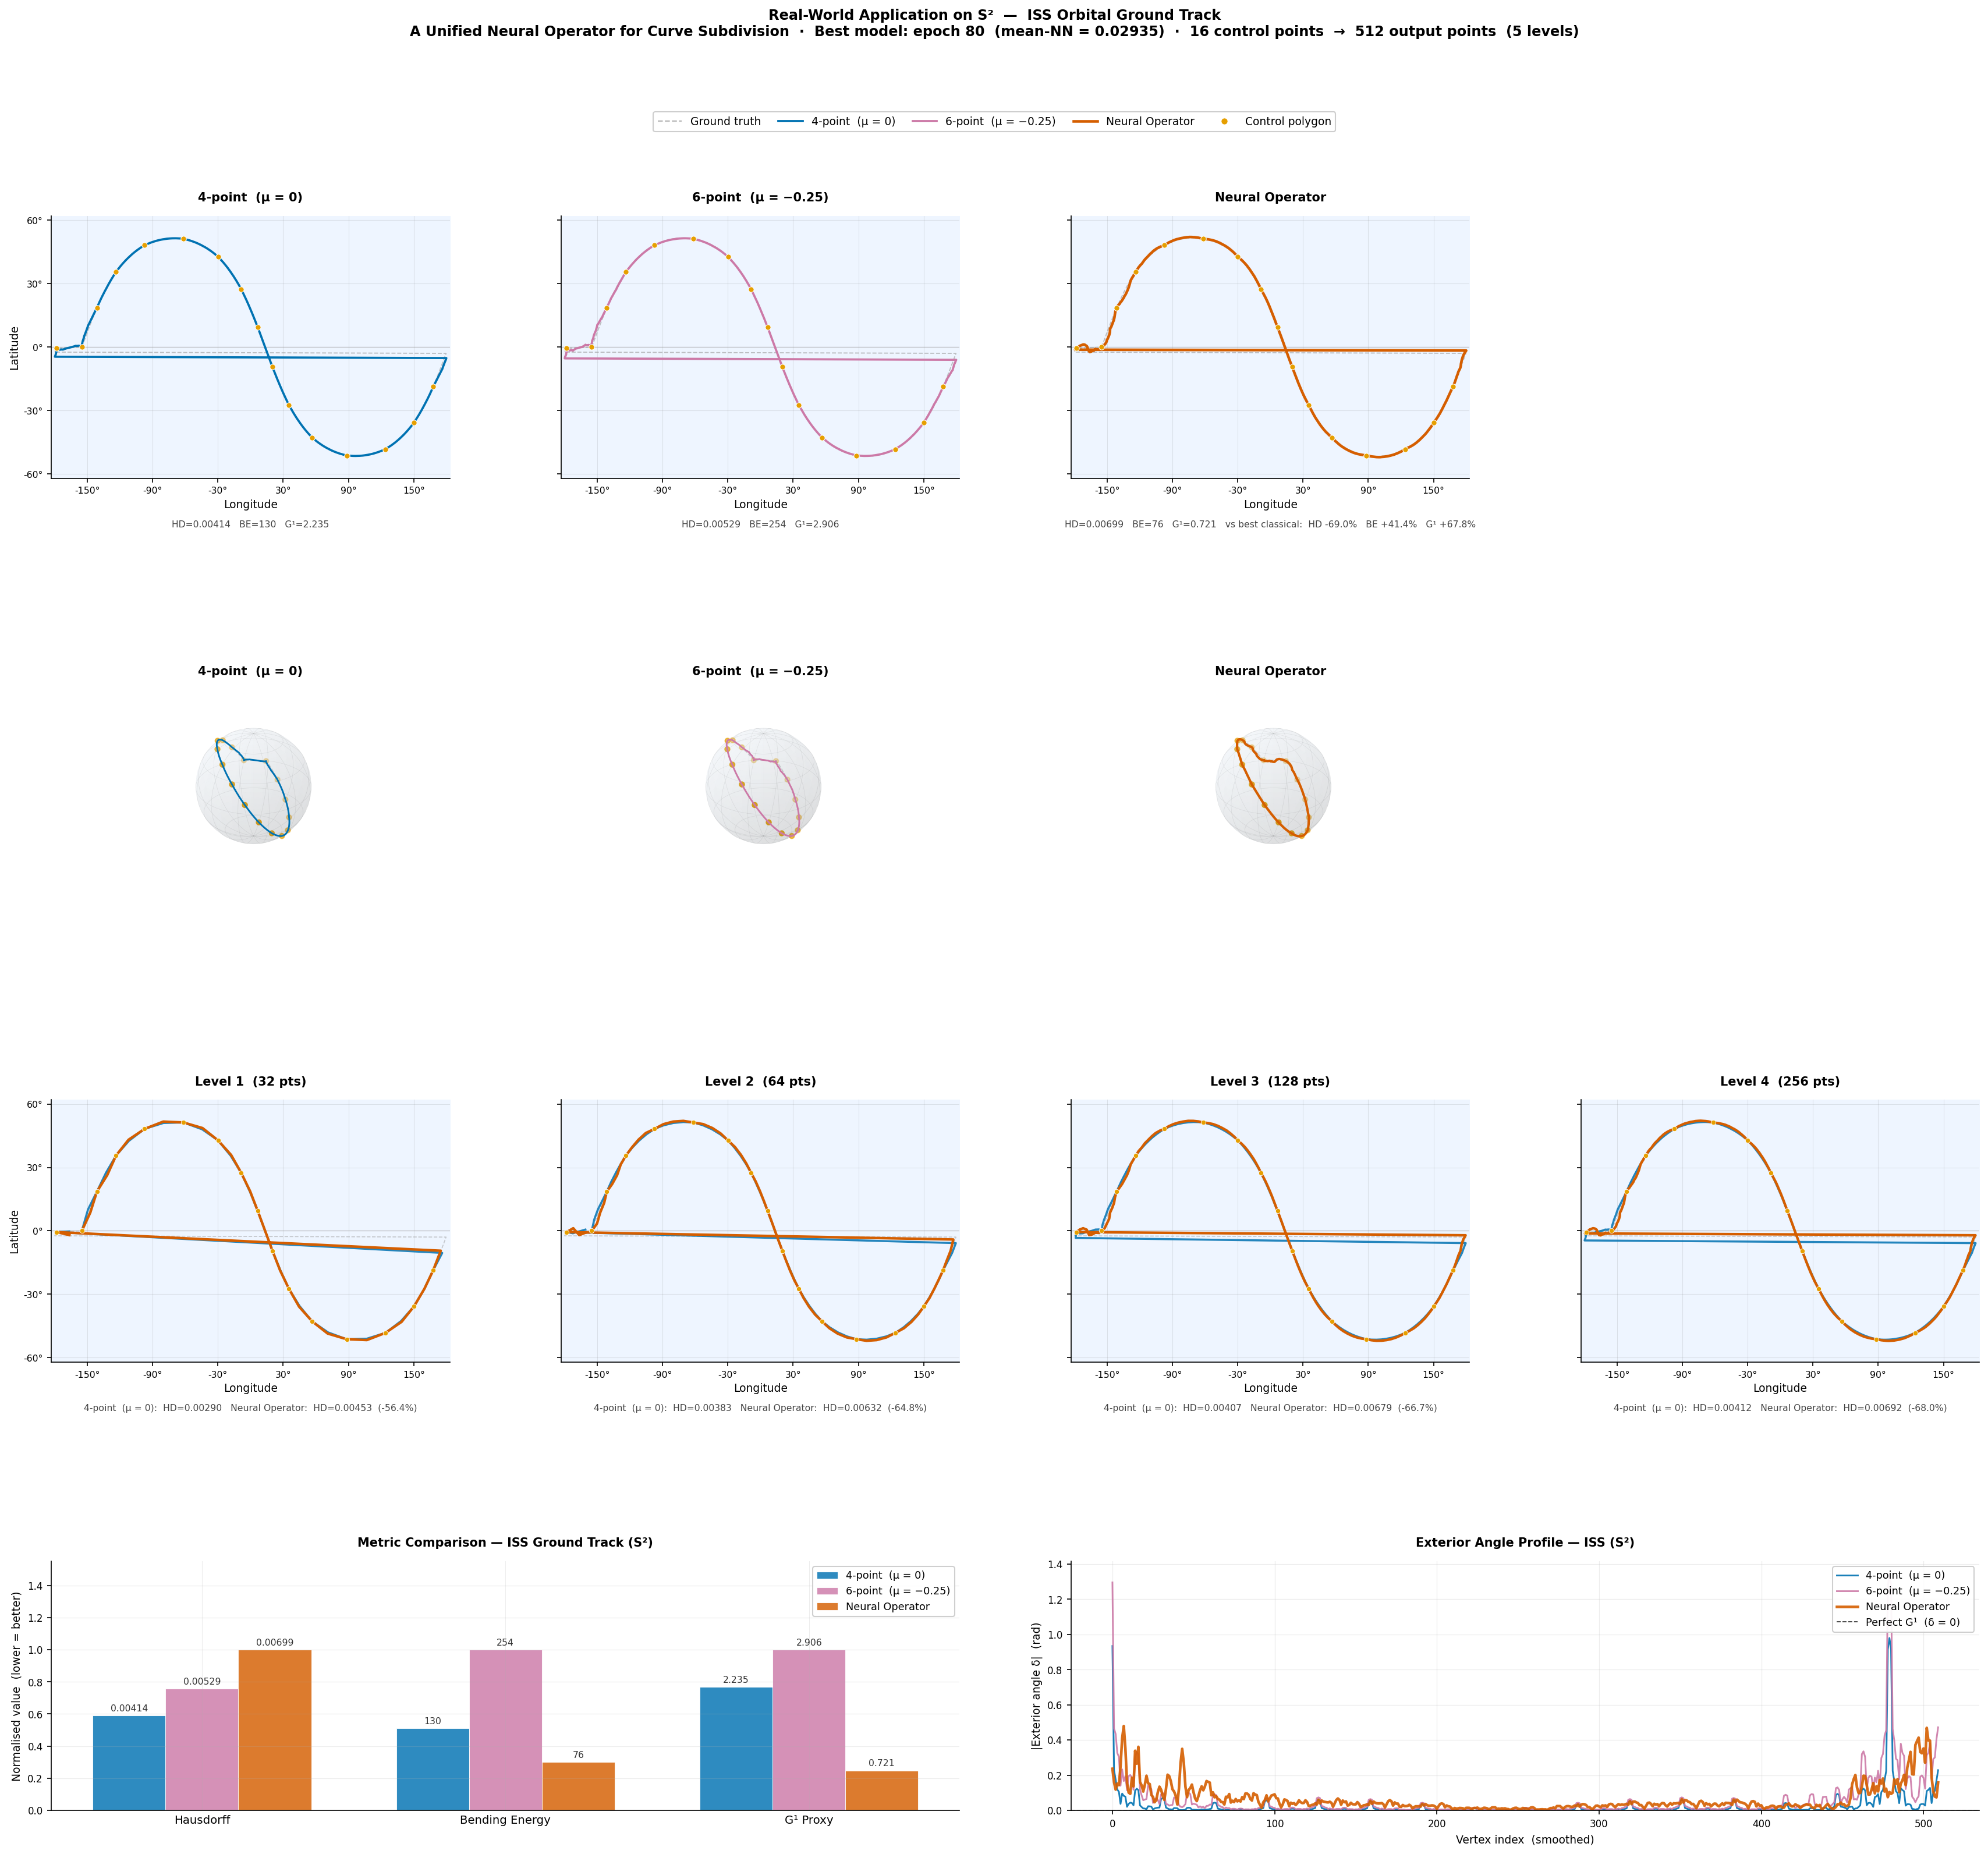


Composite saved  →  outputs/fig5_realworld_iss.png

[Fig 5 — ISS panels @ 300 DPI]
    iss/fig5_map_4pt.png
    iss/fig5_map_6pt.png
    iss/fig5_map_neural.png
    iss/fig5_refine_l1.png
    iss/fig5_refine_l2.png
    iss/fig5_refine_l3.png
    iss/fig5_refine_l4.png
  ✓  7 ISS panels saved


In [ ]:
# =============================================================================
# SECTION C  —  Real-world application on S²
#               International Space Station (ISS) orbital ground track
# =============================================================================

import numpy as np
import torch
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ── 0.  Reload best checkpoint ────────────────────────────────────────────────
_ckpt_path = OUTDIR / 'best_model.pt'
assert _ckpt_path.exists(), (
    f"\n  best_model.pt not found at {_ckpt_path.resolve()}"
    "\n  Re-run the training cell to generate it.")

_ckpt = torch.load(_ckpt_path, map_location=DEVICE)
model.load_state_dict(_ckpt['state_dict'])
model.eval()
_ep, _vhd = _ckpt['epoch'], _ckpt.get('val_mean_nn', _ckpt.get('val_hd', float('nan')))
print(f"Checkpoint  :  epoch {_ep},  cross-geom mean-NN = {_vhd:.5f}")
if _ep < 100:
    print(f"  ⚠  WARNING: partial checkpoint (epoch {_ep}) — figures are preview only.")
else:
    print("  ✓  Full checkpoint — publication quality.")

# ── 1.  Style ─────────────────────────────────────────────────────────────────
matplotlib.rcParams.update({
    'font.family':         'DejaVu Sans',
    'font.size':            9,
    'axes.titlesize':      10,
    'axes.titleweight':    'bold',
    'axes.labelsize':       9,
    'xtick.labelsize':      8,
    'ytick.labelsize':      8,
    'legend.fontsize':      8.5,
    'legend.framealpha':    0.94,
    'legend.edgecolor':    '#cccccc',
    'legend.handlelength':  2.0,
    'axes.spines.top':     False,
    'axes.spines.right':   False,
})

C4    = PALETTE['4pt']
C6    = PALETTE['6pt']
CNN   = PALETTE['neural']
CCTRL = PALETTE['ctrl']
CGT   = PALETTE['gt']

_LBL = {
    '4pt':    '4-point  (μ = 0)',
    '6pt':    '6-point  (μ = −0.25)',
    'neural': 'Neural Operator',
    'gt':     'Ground truth',
    'ctrl':   'Control polygon',
}

# ── 2.  Coordinate utilities ──────────────────────────────────────────────────
def _ll2xyz(lat_deg, lon_deg):
    la  = np.radians(np.asarray(lat_deg, dtype=np.float64))
    lo  = np.radians(np.asarray(lon_deg, dtype=np.float64))
    xyz = np.stack([np.cos(la)*np.cos(lo),
                    np.cos(la)*np.sin(lo),
                    np.sin(la)], axis=1).astype(np.float32)
    return xyz / (np.linalg.norm(xyz, axis=1, keepdims=True) + 1e-9)

def _xyz2ll(xyz):
    n   = np.linalg.norm(xyz, axis=1, keepdims=True)
    xyz = (xyz / (n + 1e-9)).astype(np.float64)
    return (np.degrees(np.arcsin(xyz[:, 2].clip(-1, 1))),
            np.degrees(np.arctan2(xyz[:, 1], xyz[:, 0])))

def _geodesic(p1, p2, n=50):
    omega = np.arccos(float(np.clip(np.dot(p1, p2), -1, 1)))
    if omega < 1e-7:
        return np.tile(p1.astype(np.float32), (n, 1))
    s   = np.linspace(0, 1, n, endpoint=False)
    pts = (np.sin((1-s[:,None])*omega)*p1 +
           np.sin(   s[:,None] *omega)*p2) / np.sin(omega)
    return (pts / np.linalg.norm(pts, axis=1, keepdims=True)).astype(np.float32)

def _arclength_sample(curve, n):
    d   = np.linalg.norm(np.diff(curve, axis=0), axis=1)
    arc = np.concatenate([[0.], np.cumsum(d)])
    idx = np.searchsorted(arc, np.linspace(0, arc[-1], n, endpoint=False))
    return curve[idx.clip(0, len(curve)-1)]

# ── 3.  ISS ground track ──────────────────────────────────────────────────────
I_DEG    = 51.64
T_MIN    = 92.68
W_E      = 360.0 / (23*60 + 56.067)
LON0     = -155.0
N_PASS   = 480
N_BRIDGE = 40

i_rad   = np.radians(I_DEG)
t_arr   = np.linspace(0, T_MIN, N_PASS, endpoint=False)
theta   = 2*np.pi * t_arr / T_MIN

lat_p   = np.degrees(np.arcsin(np.sin(i_rad) * np.sin(theta)))
lon_eci = np.degrees(np.arctan2(np.cos(i_rad)*np.sin(theta), np.cos(theta)))
lon_p   = ((lon_eci - W_E*t_arr + LON0 + 180) % 360) - 180

xyz_p   = _ll2xyz(lat_p, lon_p)
xyz_br  = _geodesic(xyz_p[-1], xyz_p[0], n=N_BRIDGE)

gt_xyz  = np.vstack([xyz_p, xyz_br]).astype(np.float32)
gt_xyz /= np.linalg.norm(gt_xyz, axis=1, keepdims=True) + 1e-9

gt_lat, gt_lon = _xyz2ll(gt_xyz)
print(f"\nISS ground track  :  {len(gt_xyz)} points  "
      f"(lat ∈ [{gt_lat.min():.1f}°, {gt_lat.max():.1f}°])")

# ── 4.  Control polygon and subdivision ──────────────────────────────────────
N_CTRL  = 16
N_ITERS = 5

ctrl_xyz = _arclength_sample(gt_xyz, N_CTRL)
ctrl_lat, ctrl_lon = _xyz2ll(ctrl_xyz)

@torch.no_grad()
def _subdivide(ctrl_np, n_iters):
    P   = torch.tensor(ctrl_np, device=DEVICE, dtype=torch.float32)
    GT  = torch.tensor(gt_xyz,  device=DEVICE, dtype=torch.float32)
    out = {}
    for mk, sub in [
        ('4pt',    classical_subdivide(P, 'spherical', mu=0.0,   n_iters=n_iters)),
        ('6pt',    classical_subdivide(P, 'spherical', mu=-0.25, n_iters=n_iters)),
        ('neural', neural_subdivide(P, model, 'spherical', n_iters=n_iters)),
    ]:
        out[mk] = {
            'curve':     sub.cpu().numpy(),
            'hausdorff': torch.cdist(sub, GT).min(1).values.mean().item(),
            'bending':   bending_energy(sub, 'spherical').item(),
            'g1_proxy':  sph_exterior_angles(sub).abs().max().item(),
        }
    return out

res     = _subdivide(ctrl_xyz, N_ITERS)
best_cl = '4pt' if res['4pt']['hausdorff'] <= res['6pt']['hausdorff'] else '6pt'
bcl_hd  = res[best_cl]['hausdorff']
bcl_be  = res[best_cl]['bending']
bcl_g1  = res[best_cl]['g1_proxy']
imp_hd  = (1 - res['neural']['hausdorff'] / max(bcl_hd, 1e-9)) * 100
imp_be  = (1 - res['neural']['bending']   / max(bcl_be, 1e-9)) * 100
imp_g1  = (1 - res['neural']['g1_proxy']  / max(bcl_g1, 1e-9)) * 100
best_cl_col = C4 if best_cl == '4pt' else C6

print(f"\n{'Method':<28} {'Hausdorff':>10} {'Bending':>12} {'G¹ proxy':>10}")
print("─" * 64)
for mk in ['4pt', '6pt', 'neural']:
    r = res[mk]
    print(f"{_LBL[mk]:<28} {r['hausdorff']:>10.5f} "
          f"{r['bending']:>12.1f}  {r['g1_proxy']:>10.4f}")
print("\n  Improvement  (Neural Operator vs best classical):")
print(f"    Hausdorff {imp_hd:+.1f}%    Bending {imp_be:+.1f}%    G¹ {imp_g1:+.1f}%")

# ── 5.  Shared drawing helpers (used by both composite and individual) ────────
MAP_XLIM = (-183, 183)
MAP_YLIM = ( -62,  62)
XTKS     = np.arange(-150, 181, 60)
YTKS     = np.arange( -60,  61, 30)

def _style_map(ax, bold_title, sub_title, show_ylabel=True,
               fontsize_title=10, fontsize_tick=7.5, fontsize_sub=7.5):
    ax.set_xlim(*MAP_XLIM); ax.set_ylim(*MAP_YLIM)
    ax.set_xticks(XTKS)
    ax.set_xticklabels([f'{x}°' for x in XTKS], fontsize=fontsize_tick)
    ax.set_yticks(YTKS)
    if show_ylabel:
        ax.set_yticklabels([f'{y}°' for y in YTKS], fontsize=fontsize_tick)
        ax.set_ylabel('Latitude', fontsize=fontsize_title-1, labelpad=3)
    else:
        ax.set_yticklabels([])
    ax.set_xlabel('Longitude', fontsize=fontsize_title-1, labelpad=3)
    ax.grid(True, alpha=0.20, lw=0.5, color='#888888', zorder=0)
    ax.axhline(0, color='#aaaaaa', lw=0.7, alpha=0.5, zorder=1)
    ax.fill_between([-183,183], [-62,-62], [62,62], color='#eef5ff', zorder=-1)
    ax.set_title(bold_title, fontsize=fontsize_title, fontweight='bold', pad=12)
    ax.text(0.5, -0.16, sub_title, transform=ax.transAxes,
            ha='center', va='top', fontsize=fontsize_sub,
            color='#444444', clip_on=False)

def _draw_globe(ax3d, curve_xyz, col, lw, label, elev=28, azim=15, fontsize_title=10):
    u = np.linspace(0, 2*np.pi, 60)
    v = np.linspace(0, np.pi,   30)
    ax3d.plot_surface(
        np.outer(np.cos(u), np.sin(v)),
        np.outer(np.sin(u), np.sin(v)),
        np.outer(np.ones_like(u), np.cos(v)),
        color='#ddeeff', alpha=0.10, linewidth=0, antialiased=True, zorder=0)
    for la in range(-60, 90, 30):
        lr = np.radians(la); lo = np.linspace(0, 2*np.pi, 120)
        ax3d.plot(np.cos(lr)*np.cos(lo), np.cos(lr)*np.sin(lo),
                  np.full_like(lo, np.sin(lr)), color='#bbbbbb', lw=0.3, alpha=0.35)
    for lo in range(0, 360, 30):
        lr = np.radians(lo); la = np.linspace(-np.pi/2, np.pi/2, 60)
        ax3d.plot(np.cos(la)*np.cos(lr), np.cos(la)*np.sin(lr),
                  np.sin(la), color='#bbbbbb', lw=0.3, alpha=0.35)
    ax3d.plot(gt_xyz[:,0], gt_xyz[:,1], gt_xyz[:,2],
              '--', color=CGT, lw=0.8, alpha=0.50, zorder=2)
    ax3d.plot(curve_xyz[:,0], curve_xyz[:,1], curve_xyz[:,2],
              color=col, lw=lw, zorder=5)
    ax3d.scatter(ctrl_xyz[:,0], ctrl_xyz[:,1], ctrl_xyz[:,2],
                 color=CCTRL, s=16, zorder=6)
    ax3d.view_init(elev=elev, azim=azim)
    ax3d.set_box_aspect([1, 1, 1])
    ax3d.axis('off')
    ax3d.set_title(label, fontsize=fontsize_title, fontweight='bold', pad=2)

def _iss_leg_handles():
    return [
        Line2D([0],[0], color=CGT,   lw=1.1, ls='--', alpha=0.7, label=_LBL['gt']),
        Line2D([0],[0], color=C4,    lw=1.8,           label=_LBL['4pt']),
        Line2D([0],[0], color=C6,    lw=1.8,           label=_LBL['6pt']),
        Line2D([0],[0], color=CNN,   lw=2.2,           label=_LBL['neural']),
        Line2D([0],[0], color=CCTRL, lw=0, marker='o', ms=5.5,
               markeredgewidth=0.5, markeredgecolor='white', label=_LBL['ctrl']),
    ]

def _map_subtitle(mk):
    r = res[mk]
    if mk == 'neural':
        return (f"HD={r['hausdorff']:.5f}   BE={r['bending']:.0f}"
                f"   G¹={r['g1_proxy']:.3f}"
                f"   vs best classical:  HD {imp_hd:+.1f}%"
                f"   BE {imp_be:+.1f}%   G¹ {imp_g1:+.1f}%")
    return (f"HD={r['hausdorff']:.5f}   "
            f"BE={r['bending']:.0f}   G¹={r['g1_proxy']:.3f}")

# ── 6.  Pre-compute bar chart data (shared by composite + panels) ─────────────
bar_col  = {'4pt': C4, '6pt': C6, 'neural': CNN}
m_keys   = ['hausdorff', 'bending', 'g1_proxy']
m_lbl    = ['Hausdorff', 'Bending Energy', 'G¹ Proxy']
raw_vals = {mk: [res[mk][m] for m in m_keys] for mk in ['4pt','6pt','neural']}
maxv     = [max(raw_vals[mk][j] for mk in ['4pt','6pt','neural'])+1e-12 for j in range(3)]
norm_v   = {mk: [raw_vals[mk][j]/maxv[j] for j in range(3)] for mk in ['4pt','6pt','neural']}
x, w     = np.arange(3), 0.24

# ── 7.  Composite overview figure (180 DPI) ───────────────────────────────────
fig = plt.figure(figsize=(24, 22))
gs  = gridspec.GridSpec(4, 4, figure=fig,
                        height_ratios=[1.0, 0.85, 1.0, 0.95],
                        hspace=0.80, wspace=0.28,
                        left=0.05, right=0.97, top=0.89, bottom=0.06)

fig.legend(handles=_iss_leg_handles(), loc='upper center',
           bbox_to_anchor=(0.50, 0.947), ncol=5, fontsize=9,
           framealpha=0.96, edgecolor='#cccccc',
           columnspacing=1.6, handlelength=2.2)

for ci, mk in enumerate(['4pt', '6pt', 'neural']):
    ax  = fig.add_subplot(gs[0, ci])
    col = [C4, C6, CNN][ci]
    lw  = 2.2 if mk == 'neural' else 1.8
    _style_map(ax, bold_title=_LBL[mk], sub_title=_map_subtitle(mk),
               show_ylabel=(ci == 0))
    ax.plot(gt_lon,   gt_lat,   '--', color=CGT,  lw=0.9, alpha=0.60, zorder=2)
    c_lat, c_lon = _xyz2ll(res[mk]['curve'])
    ax.plot(c_lon,    c_lat,    '-',  color=col,  lw=lw,  zorder=3)
    ax.plot(ctrl_lon, ctrl_lat, 'o',  color=CCTRL, ms=4.5, zorder=5,
            markeredgewidth=0.5, markeredgecolor='white')

for ci, (mk, col, lw, label) in enumerate([
    ('4pt', C4, 1.4, _LBL['4pt']),
    ('6pt', C6, 1.4, _LBL['6pt']),
    ('neural', CNN, 2.0, _LBL['neural']),
]):
    ax3d = fig.add_subplot(gs[1, ci], projection='3d')
    _draw_globe(ax3d, res[mk]['curve'], col=col, lw=lw, label=label)

for lvl in range(1, 5):
    ax  = fig.add_subplot(gs[2, lvl-1])
    rv  = _subdivide(ctrl_xyz, lvl)
    n_p = len(rv['neural']['curve'])
    cl_hd  = rv[best_cl]['hausdorff']
    nn_hd  = rv['neural']['hausdorff']
    lv_imp = (1 - nn_hd / max(cl_hd, 1e-9)) * 100
    sub = (f"{_LBL[best_cl]}:  HD={cl_hd:.5f}   "
           f"Neural Operator:  HD={nn_hd:.5f}  ({lv_imp:+.1f}%)")
    _style_map(ax, bold_title=f'Level {lvl}  ({n_p} pts)', sub_title=sub,
               show_ylabel=(lvl == 1))
    ax.plot(gt_lon, gt_lat, '--', color=CGT, lw=0.8, alpha=0.50, zorder=2)
    c_lat_cl, c_lon_cl = _xyz2ll(rv[best_cl]['curve'])
    ax.plot(c_lon_cl, c_lat_cl, '-', color=best_cl_col, lw=1.7, alpha=0.85, zorder=3)
    c_lat_nn, c_lon_nn = _xyz2ll(rv['neural']['curve'])
    ax.plot(c_lon_nn, c_lat_nn, '-', color=CNN, lw=2.1, zorder=4)
    ax.plot(ctrl_lon, ctrl_lat, 'o', color=CCTRL, ms=4, zorder=5,
            markeredgewidth=0.4, markeredgecolor='white')

ax_bar = fig.add_subplot(gs[3, 0:2])
for i, mk in enumerate(['4pt', '6pt', 'neural']):
    bars = ax_bar.bar(x+(i-1)*w, norm_v[mk], w, color=bar_col[mk],
                      alpha=0.82, edgecolor='white', lw=0.5, label=_LBL[mk])
    for j, (bar, rv2) in enumerate(zip(bars, raw_vals[mk])):
        fmt = (f'{rv2:.5f}' if j==0 else f'{rv2:.0f}' if rv2>=10 else f'{rv2:.3f}')
        ax_bar.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.016, fmt,
                    ha='center', va='bottom', fontsize=7.5, color='#333333')
ax_bar.set_xticks(x); ax_bar.set_xticklabels(m_lbl, fontsize=9.5)
ax_bar.set_ylabel('Normalised value  (lower = better)', fontsize=9)
ax_bar.set_ylim(0, 1.55); ax_bar.tick_params(axis='x', length=0)
ax_bar.grid(axis='y', alpha=0.22, lw=0.6, zorder=0)
ax_bar.set_title('Metric Comparison — ISS Ground Track (S²)',
                 fontsize=10, fontweight='bold', pad=12)
ax_bar.legend(loc='upper right', fontsize=8.5, framealpha=0.94, edgecolor='#cccccc')

ax_ang = fig.add_subplot(gs[3, 2:4])
for mk in ['4pt', '6pt', 'neural']:
    sub_t = torch.tensor(res[mk]['curve'], device=DEVICE, dtype=torch.float32)
    d_ang = sph_exterior_angles(sub_t).abs().cpu().numpy()
    sm    = max(1, len(d_ang)//160)
    ds    = np.convolve(d_ang, np.ones(sm)/sm, 'valid')
    lw    = 2.2 if mk == 'neural' else 1.4
    ax_ang.plot(ds, color=bar_col[mk], lw=lw, alpha=0.90, label=_LBL[mk])
ax_ang.axhline(0, color='#444444', lw=0.9, ls='--', label='Perfect G¹  (δ = 0)')
ax_ang.set_xlabel('Vertex index  (smoothed)', fontsize=9)
ax_ang.set_ylabel('|Exterior angle δ|  (rad)', fontsize=9)
ax_ang.set_ylim(bottom=0)
ax_ang.grid(alpha=0.22, lw=0.6, zorder=0)
ax_ang.set_title('Exterior Angle Profile — ISS (S²)',
                 fontsize=10, fontweight='bold', pad=12)
ax_ang.legend(loc='upper right', fontsize=8.5, framealpha=0.94, edgecolor='#cccccc')

fig.suptitle(
    'Real-World Application on S²  —  ISS Orbital Ground Track\n'
    'A Unified Neural Operator for Curve Subdivision  ·  '
    f'Best model: epoch {_ep}  (mean-NN = {_vhd:.5f})  ·  '
    f'{N_CTRL} control points  →  {len(res["neural"]["curve"])} output points'
    f'  ({N_ITERS} levels)',
    fontsize=11.5, fontweight='bold', y=0.998)

out_path = OUTDIR / 'fig5_realworld_iss.png'
fig.savefig(out_path, dpi=180, bbox_inches='tight', facecolor='white')
plt.show(); plt.close(fig)
print(f"\nComposite saved  →  {out_path}")

# ── 8.  Individual panels @ 300 DPI via save_iss_panels() ────────────────────
#
#  save_iss_panels() is defined in Cell 27 alongside the Fig 1–4 helpers.
#  We pass it a dict of everything it needs so it has no hidden dependencies.

iss_data = dict(
    res=res,
    gt_xyz=gt_xyz, gt_lat=gt_lat, gt_lon=gt_lon,
    ctrl_xyz=ctrl_xyz, ctrl_lat=ctrl_lat, ctrl_lon=ctrl_lon,
    best_cl=best_cl, best_cl_col=best_cl_col,
    imp_hd=imp_hd, imp_be=imp_be, imp_g1=imp_g1,
    ep=_ep, vhd=_vhd, n_ctrl=N_CTRL, n_iters=N_ITERS,
    subdivide_fn=_subdivide,
    style_map=_style_map,
    draw_globe=_draw_globe,
    leg_handles=_iss_leg_handles(),
    LBL=_LBL,
    bar_col=bar_col, m_keys=m_keys, m_lbl=m_lbl,
    raw_vals=raw_vals, maxv=maxv, norm_v=norm_v, x=x, w=w,
)

save_iss_panels(iss_data)


## Save to Google Drive  (optional)

## Reload and run inference on a custom polygon

In [ ]:
#
dst = Path('/content/drive/MyDrive/Colab Notebooks/TEMP/Subdivision/Results')
dst.mkdir(parents=True, exist_ok=True)
shutil.copytree(OUTDIR, dst/'outputs', dirs_exist_ok=True)
torch.save(model.state_dict(), dst/'geomsubnet_v3_final.pt')
print(f"Saved to {dst}")

Saved to /content/drive/MyDrive/Colab Notebooks/TEMP/Subdivision/Results


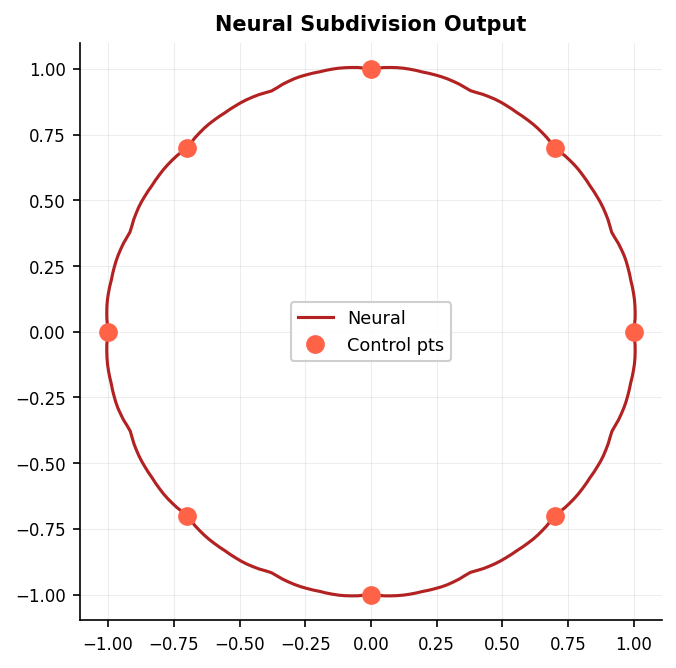

In [ ]:
model_new = NeuralOperator(hidden=CFG['hidden'], n_res_blocks=CFG['n_res_blocks']).to(DEVICE)
ckpt = torch.load(OUTDIR/'best_model.pt', map_location=DEVICE)
model_new.load_state_dict(ckpt['state_dict'])
model_new.eval()
# #
my_polygon = torch.tensor([
     [1.,0.],[.7,.7],[0.,1.],[-.7,.7],
     [-1.,0.],[-.7,-.7],[0.,-1.],[.7,-.7],
     ], dtype=torch.float32, device=DEVICE)
# #
with torch.no_grad():
     refined = neural_subdivide(my_polygon, model_new, 'euclidean', n_iters=5)
#
pts = refined.cpu().numpy()
plt.figure(figsize=(5,5))
plt.plot(pts[:,0], pts[:,1], 'firebrick', lw=1.5, label='Neural')
plt.plot(my_polygon[:,0].cpu(), my_polygon[:,1].cpu(),
          'o', color='tomato', ms=8, label='Control pts')
plt.axis('equal'); plt.legend(); plt.title('Neural Subdivision Output')
plt.show()